# Improved ΔQ Model for Linear Leios EB Diffusion

*Self-contained, standalone interactive analysis notebook.*  All analysis code
is inlined and plots render inline.  Key parameter blocks are marked `# === edit ===` — change
them and re-run the cell to explore the numbers.

## 1. Executive Summary

This notebook presents a corrected and extended ΔQ analysis of Endorser Block
(EB) diffusion in Linear Leios.  It fixes three structural bugs in the
previous analysis, uses a proper numerical (discretized CDF) backend,
re-derives the per-transaction timing constants from the empirical
`block-edf.csv` dataset, and instantiates the model under **two TCP
congestion-control models** — **Reno** (via the Mathis equation) and **CUBIC**
— to bound the network-induced sensitivity.

**Bottom line.** Under the 1-hop approximation and the Praos paper's RTT
values, the 12 MB CIP target is robustly feasible under both throughput
models — the Mathis-vs-CUBIC distinction is immaterial at every tested size.
$P_\text{cert}$ stays at the Praos cap of $\approx 0.497$ across the full
0–12 MB sweep under both models.

The certification probability is capped at $\approx 0.497$ by the Praos
leader schedule whenever quorum is met (independent of throughput model).
The **1-hop approximation is the remaining load-bearing assumption**: under
total pre-diffusion failure the effective $P_\text{cert}$ collapses to ≈ 0
under either throughput model at 12 MB.


## 2. Protocol Recap

Linear Leios extends Ouroboros Praos by adding Endorser Blocks (EBs).  The
relevant timing pipeline (one round) is:

```
  slot:  |---L_hdr---|---L_hdr---|---L_hdr---|---L_vote---|---L_diff---|
             (1) RB    (2) EB      (3) cert    voting wdw   EB body
             header    header      header                   + cert
             diffuses  diffuses    diffuses                 diffuses
  total: 3×L_hdr + L_vote + L_diff = 3+4+7 = 14 slots
```

An EB is certified when the committee votes collected within the voting window
(by slot $3 L_\text{hdr}+L_\text{vote}=7$) carry at least a fraction τ of the
**total active stake** — $\sum_{v\in\text{votes}}\text{stake}(v)\ge\tau\cdot
\text{stake}_\text{total-active}$, with τ = 75% (CIP-0164).  The quorum is on
**stake, not a head-count of voters**.  The voting committee is
**deterministic**, not sampled by sortition: pools are ordered by active stake
(descending) and selected until their cumulative stake reaches a target σ_c
(equivalently the truncation error falls below ε_c = 1 − σ_c); the set is fixed
for the epoch and every member may vote on every EB (no per-EB lottery, no
non-persistent voters).  If certified, the next ranking block (RB) carries the
EB certificate rather than transactions.

*Illustrative parameters used throughout this analysis* — $L_\text{hdr}=1$,
$L_\text{vote}=4$, $L_\text{diff}=7$ (⇒ 14 slots), committee cover σ_c ≈ 0.99 —
are example values consistent with the CIP's constraints (e.g.
$3 L_\text{hdr}+L_\text{vote}>\Delta_\text{EB}^{O}$); the CIP fixes none of
them, they are governance-tunable.

**RB structure (critical):** An RB contains *either* an EB certificate
(certRB) *or* transactions (txRB), never both simultaneously.  The prior
analysis forced both paths in parallel — this is incorrect.


## 3. Bugs Fixed in the Prior Analysis

### 3.1 RB path structure

Original code (`DeltaQ/Leios.hs`, line 128):
```haskell
processRBandEB = processRB ./\. processEB   -- WRONG: forces both paths
```
Fixed: use a probabilistic choice weighted by $P_{certified}$:
```
cdf_validate_rb(p_cert) = p_cert × certRB_path + (1-p_cert) × txRB_path
```

### 3.2 EB closure size

The original model had no parametric EB closure size. The block size used for
diffusion was a fixed uniform choice {1, 64, 256, 512} kB, and the reapply
distribution used a hardcoded N=2500 transactions.

Fixed: the EB closure is parameterised by $S_{EB-tx}$, the total closure size,
and `reapply_txs_cdf(s_eb_tx_kb)` derives the correct number of transactions:

$$N_{txs} = \min\left(\lfloor S_{EB-tx} / \overline{t_x} \rfloor,\; 16000\right)$$

where $\overline{t_x}$ = 1 kB (average transaction size) and 16 000 is the
maximum number of transaction references a 512 kB EB body can hold.

### 3.3 Scale mixture vs. fixed-N distribution for reapplication

The original model used a *scale mixture* for the reapply CDF:

$$F_\text{mix}(t) = \frac{1}{N}\sum_{k=1}^{N} \Phi\!\left(\frac{t - k\mu}{\sqrt{k}\,\sigma}\right)$$

This models a block of *random* size $k \sim \mathcal{U}(1, N)$ – appropriate
for the Praos `applyTxs` path where the block size is unknown, but **wrong** for
EB closure validation where the validator must process *all* $N$ transactions.

Fixed: use the CLT approximation for the *fixed-N* case:

$$F_\text{fixed}(t) = \Phi\!\left(\frac{t - N\mu}{\sqrt{N}\,\sigma}\right)$$

This is significantly more pessimistic for large $N$:

| $S_{EB-tx}$ | $N_{txs}$ | Mix model mean | Fixed-N mean (correct) |
|-------------|-----------|----------------|------------------------|
| 1 MB        | 1 024     | 73 ms          | 147 ms                 |
| 2 MB        | 2 048     | 147 ms         | 293 ms                 |
| 4 MB        | 4 096     | 293 ms         | 587 ms                 |
| 12 MB       | 12 288    | 879 ms         | 1.76 s                 |

The scale mixture underestimates the mean by exactly 2×: under $k \sim
\mathcal{U}(1, N)$ the expected work is $E[k]\mu = (N/2)\mu$ versus $N\mu$
for the fixed-N case.  With the corrected per-tx constants
($\mu_\text{eff} = 0.143$ ms/tx), the Fixed-N times are well under the
7-second voter deadline for all sizes shown, so the 2× factor no longer
changes the feasibility conclusion — but the fixed-N model is still the
correct one to use.

**Clarification on what is and is not random across validators.**
A natural question: if a validator already has all closure transactions in
its mempool, does it have less work to do — and does that make the number
of transactions processed a random variable, justifying the scale mixture?

The answer is no, for two reasons:

1. *All N transactions must be processed regardless of mempool state.*
   Even a transaction the validator has seen before must be re-checked against
   the *current* ledger state via `reapplyTx`.  Ledger state at certification
   time may differ from when the transaction first arrived.  A correct
   implementation cannot skip transactions it happens to have cached.

2. *The scale mixture models the wrong quantity as random.*
   `scaleMixtureDQ N` treats the *count* of transactions as $k \sim
   \mathcal{U}(1, N)$, implying the validator randomly skips a fraction of
   the closure.  The actual source of variability across validators is the
   *cost per transaction*, not the number of transactions: a cache hit pays
   $\mu_\text{reapply}$ while a cache miss pays $\mu_\text{apply}$.  This
   per-transaction randomness is captured correctly by the effective mean
   $\mu_\text{eff} = \pi_1 \mu_\text{apply} + \pi_2 \mu_\text{reapply}$
   (Section 4.4), with N fixed.

The number of transactions *fetched* over the network does vary across
validators (approximately $\pi_1 N$ on average), but this affects only the
network fetch step, which is modelled separately in
`cdf_fetch_missing_eb_closure`.

## 4. Model Description

### 4.1 Numerical Backend

Discretized CDF on a fixed time grid.

- Grid: $N = 4000$ points, $\Delta t = 10$ ms, $T_\text{max} = 40$ s
- Sequential composition: FFT-based convolution — $O(N \log N)$
- All other operators (last-to-finish, first-to-finish, choice): pointwise

This is equivalent in design to the `Discretized` Haskell module proposed in
the `deltaq/mw/approx` branch.  The 10 ms resolution is sufficient for this
analysis (timing differences relevant to the protocol are on the order of
100 ms or larger).


In [1]:
%matplotlib inline
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

# ---------------------------------------------------------------------------
# GLOBAL GRID PARAMETERS
# ---------------------------------------------------------------------------

T_MAX = 40.0  # seconds – covers all realistic completion times
N = 4000  # number of grid points
DT = T_MAX / N  # = 0.010 s per step  (10 ms resolution)

TIMES = np.arange(1, N + 1) * DT  # [DT, 2DT, ..., T_MAX]


# ---------------------------------------------------------------------------
# DISCRETIZED CDF PRIMITIVES
# ---------------------------------------------------------------------------


def cdf_never() -> np.ndarray:
    """Outcome that never finishes: CDF = 0 everywhere."""
    return np.zeros(N)


def cdf_wait(t: float) -> np.ndarray:
    """Deterministic wait: P(X <= t') = 1 if t' >= t, else 0."""
    return np.where(TIMES >= t, 1.0, 0.0)


def cdf_uniform(a: float, b: float) -> np.ndarray:
    """Uniform distribution on [a, b]."""
    if a >= b:
        return cdf_wait(a)
    return np.clip((TIMES - a) / (b - a), 0.0, 1.0)


def cdf_choice(p: float, cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Probabilistic choice: p * cdf1 + (1-p) * cdf2."""
    return p * cdf1 + (1.0 - p) * cdf2


def cdf_choices(weighted: list) -> np.ndarray:
    """choices [(w1, cdf1), (w2, cdf2), ...]  (weights unnormalised)."""
    total = sum(w for w, _ in weighted)
    result = np.zeros(N)
    for w, cdf in weighted:
        result += (w / total) * cdf
    return result


def _to_pdf(cdf: np.ndarray) -> np.ndarray:
    """CDF → PDF (first differences)."""
    pdf = np.empty(N)
    pdf[0] = cdf[0]
    pdf[1:] = np.diff(cdf)
    return pdf


def cdf_sequential(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Sequential composition (convolution of PDFs) via FFT."""
    pdf1 = _to_pdf(cdf1)
    pdf2 = _to_pdf(cdf2)
    n2 = 2 * N
    conv = np.fft.irfft(np.fft.rfft(pdf1, n2) * np.fft.rfft(pdf2, n2), n2)[:N]
    conv = np.maximum(conv, 0.0)  # clamp FFT artefacts
    result = np.cumsum(conv)
    return np.minimum(result, 1.0)  # clamp to [0, 1]


def cdf_last_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """Last-to-finish (max): P(max(X,Y) <= t) = F_X(t) * F_Y(t)."""
    return cdf1 * cdf2


def cdf_first_to_finish(cdf1: np.ndarray, cdf2: np.ndarray) -> np.ndarray:
    """First-to-finish (min): P(min(X,Y) <= t) = 1-(1-F_X)(1-F_Y)."""
    return cdf1 + cdf2 - cdf1 * cdf2


def success_within(cdf: np.ndarray, t: float) -> float:
    """P(X <= t)."""
    if t <= 0.0:
        return 0.0
    idx = min(int(t / DT) - 1, N - 1)
    return float(cdf[idx]) if idx >= 0 else 0.0


def quantile_of(cdf: np.ndarray, p: float) -> float:
    """Smallest t such that P(X <= t) >= p."""
    if p <= 0.0:
        return 0.0
    idx = int(np.searchsorted(cdf, p, side="left"))
    return float("inf") if idx >= N else (idx + 1) * DT


def failure_prob(cdf: np.ndarray) -> float:
    """P(X never completes within T_MAX)."""
    return 1.0 - float(cdf[-1])



### 4.2 Network Model

Path-length distribution (multi-hop diffusion) from the Praos model
(regular random graph, 2500 nodes, degree 10):

| Path length | Probability (%) |
|-------------|-----------------|
| 1           | 0.40            |
| 2           | 3.91            |
| 3           | 31.06           |
| 4           | 61.85           |
| 5           | 2.78            |

**Single-hop transfer time** is modelled using **TCP slow start** with a
selectable steady-state congestion-control model.

| Parameter     | Value      |
|---------------|-----------|
| MSS           | 1460 B    |
| Initial cwnd  | 10 MSS    |
| Loss rate $p$ | $10^{-4}$ |
| Link cap      | 1 Gbit/s  |
| OWD short     | 6 ms (RTT 12 ms)   |
| OWD medium    | 34.5 ms (RTT 69 ms) |
| OWD long      | 134 ms (RTT 268 ms) |

**OWD provenance.** The one-way delays are derived from Table 1 of the
original Praos report (`docs/deltaq_PraosModel.pdf` §3), whose "RTT"
column gives round-trip times of 12 / 69 / 268 ms for short / medium /
long distances; we halve those to get one-way delays.  (Prior versions
of this file used the Praos RTT values as OWDs, effectively doubling
the RTT; Log 023 documents the convention fix.)

**Common TCP assumptions:**
- Persistent TCP connection (no handshake overhead).
- Slow start from $\text{cwnd}_0 = 10\,\text{MSS}$; cwnd doubles each RTT.
- Throughput cap: 1 Gbit/s interface (125 MB/s).
- Packet loss $p = 10^{-4}$ (default; can be parameterised).

Steady-state windows:

| Model    | $W_\text{ss}$                                                   | $W_\text{ss}$ at $p = 10^{-4}$ |
|----------|-----------------------------------------------------------------|--------------------------------|
| Mathis   | $\text{MSS}/\sqrt{p}$                                            | 146 000 B (≈ 146 kB)           |
| CUBIC    | $\text{MSS}\cdot(C(4-\beta)/(4\beta))^{1/4}\cdot p^{-3/4}$ ($C=0.4$, $\beta=0.3$) | 1 538 590 B (≈ 1.54 MB) |

Steady-state throughputs at $p = 10^{-4}$ (Mathis: $\text{MSS}/(\text{RTT}\cdot\sqrt{p})$;
CUBIC follows the formula above; rounded to 2 sig figs):

| Distance       | RTT     | Mathis     | CUBIC                     |
|----------------|---------|------------|---------------------------|
| short          | 12 ms   | ~97 Mbps   | ~1.0 Gbps (link-capped)   |
| medium         | 69 ms   | ~17 Mbps   | ~180 Mbps                 |
| long           | 268 ms  | ~4.4 Mbps  | ~46 Mbps                  |

CUBIC's $W_\text{ss}$ assumes the "CUBIC region" (low loss); in higher-loss
conditions the real kernel reverts to a TCP-friendly Reno-like region, where
Mathis is the more faithful model.

**Lookup table.** Transfer times are pre-computed for a fixed size grid
(1 kB – 12 288 kB) from the `_tcp_transfer_time` function; intermediate
sizes use linear interpolation.  The table covers all sizes used in the
analysis (up to 12 MB), so no extrapolation is needed.  The table is
rebuilt by `set_network_model()` when switching between Mathis / CUBIC.


In [2]:
# One-way propagation delays (seconds) per distance category.
_OWD_SHORT_S = 0.006  #  6 ms one-way  →  12 ms RTT  – same datacenter / region
_OWD_MED_S = 0.0345  # 34.5 ms one-way →  69 ms RTT  – intracontinental
_OWD_LONG_S = 0.134  # 134 ms one-way → 268 ms RTT  – intercontinental

# TCP transfer-time model parameters (see §4.2 markdown for derivation).
_TCP_MSS_BYTES = 1460
_TCP_CWND0_MSS = 10
_TCP_LOSS = 1e-4
_TCP_LINK_BPS = 1e9  # 1 Gbit/s

# CUBIC constants (Ha, Rhee, Xu 2008; RFC 8312)
_TCP_CUBIC_C = 0.4  # CUBIC scaling constant
_TCP_CUBIC_BETA = 0.3  # loss-fraction (Linux kernel β_kernel = 1 - 0.3 = 0.7)


def _steady_state_window(model: str, loss: float = None) -> float:
    """Steady-state TCP window (bytes) under the chosen congestion control."""
    if loss is None:
        loss = _TCP_LOSS
    if model == "mathis":
        return _TCP_MSS_BYTES / math.sqrt(loss)
    if model == "cubic":
        pre = (_TCP_CUBIC_C * (4 - _TCP_CUBIC_BETA) / (4 * _TCP_CUBIC_BETA)) ** 0.25
        return _TCP_MSS_BYTES * pre * loss ** (-0.75)
    raise ValueError(f"Unknown network model: {model!r}")


# Active network model.  Use set_network_model() to switch.
NETWORK_MODEL = "mathis"


def _tcp_transfer_time(
    size_kb: float, owd_s: float, model: str = None, loss: float = None
) -> float:
    """
    Time (seconds) for the last byte of a size_kb kB payload to arrive at
    the receiver, modelling TCP slow start followed by a model-specific
    steady-state window cap.

    In each round the sender transmits up to cwnd bytes; cwnd doubles each RTT
    until it reaches W_ss = _steady_state_window(model), after which throughput
    is congestion-control-limited.  Transmission time at link speed is
    included (relevant for short RTTs with large payloads).
    """
    if model is None:
        model = NETWORK_MODEL

    size_bytes = size_kb * 1024
    rtt = 2.0 * owd_s
    bps = _TCP_LINK_BPS / 8.0  # bytes/s

    w_ss = _steady_state_window(model, loss)
    w_max = min(w_ss, bps * rtt)  # also bounded by BDP

    t = 0.0
    sent = 0
    cwnd = _TCP_CWND0_MSS * _TCP_MSS_BYTES

    while True:
        this = min(cwnd, size_bytes - sent)
        tx_time = this / bps
        sent += this

        if sent >= size_bytes:
            return t + tx_time + owd_s  # last bit arrives at receiver

        t += rtt  # wait for ACK before next round
        cwnd = min(cwnd * 2, w_max)


# Lookup table size grid (1 kB – 12 288 kB); see §4.2 markdown.
_SIZES_KB = [1, 64, 256, 512, 1024, 2048, 4096, 6144, 8192, 10240, 12288]


def _build_transfer_table(model: str):
    """(re)Build (short, medium, long) transfer-time lookup arrays."""
    sh = [_tcp_transfer_time(s, _OWD_SHORT_S, model) for s in _SIZES_KB]
    md = [_tcp_transfer_time(s, _OWD_MED_S, model) for s in _SIZES_KB]
    lg = [_tcp_transfer_time(s, _OWD_LONG_S, model) for s in _SIZES_KB]
    return sh, md, lg


_SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(NETWORK_MODEL)


def set_network_model(model: str):
    """
    Switch the active steady-state throughput model and rebuild the lookup
    table.  All subsequently constructed CDFs will reflect the new model.
    Caller is responsible for re-running any pre-computed analyses.
    """
    global NETWORK_MODEL, _SHORT_SEC, _MED_SEC, _LONG_SEC
    if model not in ("mathis", "cubic"):
        raise ValueError(f"Unknown network model: {model!r}")
    NETWORK_MODEL = model
    _SHORT_SEC, _MED_SEC, _LONG_SEC = _build_transfer_table(model)


def _transfer_time(distance: str, size_kb: float) -> float:
    """
    Transfer time (seconds) for a payload of size_kb kB at the given distance.
    Linearly interpolates the pre-computed TCP table.  All sizes used by the
    analysis (≤ 12 MB) are covered; no extrapolation is performed.
    """
    match distance:
        case "short":
            table = _SHORT_SEC
        case "medium":
            table = _MED_SEC
        case "long":
            table = _LONG_SEC
        case _:
            raise ValueError(f"Unknown distance: {distance}")
    return float(np.interp(size_kb, _SIZES_KB, table))


def cdf_hop(size_kb: float) -> np.ndarray:
    """Single-hop CDF for transferring size_kb kB.
    Equally probable short / medium / long distances (equal weight 1/3 each).
    """
    return cdf_choices(
        [
            (1, cdf_wait(_transfer_time("short", size_kb))),
            (1, cdf_wait(_transfer_time("medium", size_kb))),
            (1, cdf_wait(_transfer_time("long", size_kb))),
        ]
    )


def cdf_hops(n: int, size_kb: float) -> np.ndarray:
    """n sequential hops for transferring size_kb kB."""
    result = cdf_hop(size_kb)
    for _ in range(n - 1):
        result = cdf_sequential(result, cdf_hop(size_kb))
    return result


# Path-length distribution from the Praos model (regular random graph)
_HOP_PROBS = [(1, 0.40), (2, 3.91), (3, 31.06), (4, 61.85), (5, 2.78)]


def cdf_blended_delay(size_kb: float) -> np.ndarray:
    """Multi-hop blended-path delay for transferring size_kb kB."""
    return cdf_choices([(p, cdf_hops(n, size_kb)) for n, p in _HOP_PROBS])


### 4.3 Transaction Timings

From `post-cip/empirical-distributions/block-edf.csv` (mainnet measurements),
using **transaction-weighted** per-tx statistics:

| Operation  | $\mu$ (ms/tx) | $\sigma$ (ms/tx) | Use |
|------------|---------------|-------------------|-----|
| `applyTx`  | 0.507         | 0.527             | txRB path; also cache-miss txs in EB closure |
| `reapplyTx`| 0.070         | 0.265             | cache-hit txs in EB closure |

**Derivation method.** Transaction-weighted mean of `Apply[ms]/n` and
`Reapply[ms]/n` over all non-empty blocks (weight = $n_\text{txs}\times$
fraction-of-blocks), so each transaction in the dataset contributes equally.
This corrects the original Haskell constants, which were unweighted per-block
means mistakenly used as per-tx costs (≈ 25× overestimate).

`reapplyTx` is cheap because script execution results are cached from the first
`applyTx`.  A voter can only use `reapplyTx` for a transaction it has already
validated (a TxCache hit); freshly fetched cache-miss transactions require the
full `applyTx`.

The effective per-tx CPU cost mixes the two via $\pi_1$ (TxCache miss rate):

$$\mu_\text{eff} = \pi_1 \mu_\text{apply} + \pi_2 \mu_\text{reapply}
= \tfrac{1}{6}(0.507) + \tfrac{5}{6}(0.070) = 0.143\,\text{ms/tx}$$

**TxCache miss / hit rates.** From the two-state Markov model in the prior
report (§4.2) with parameters $p = 0.5$, $q = 0.9$:

$$\pi_1 = \frac{1-q}{p+1-q} = \frac{0.1}{0.6} = \frac{1}{6},\qquad
\pi_2 = 1 - \pi_1 = \frac{5}{6}.$$

These are module-level globals overridable via `set_cache_miss_rate(pi1)`
for the $\pi_1$ sensitivity sweep (§5.5).

**Block-size parameters used downstream:**

| Constant            | Value      | Meaning                                            |
|---------------------|-----------|----------------------------------------------------|
| `RB_HEADER_KB`      | 1 kB       | RB header (constant for all RBs)                   |
| `CERT_RB_BODY_KB`   | 8 kB       | certRB body: certificate, no transactions          |
| `TX_RB_BODY_KB`     | 88 kB      | txRB body (90,112 B mainnet $S_\text{RB}$)        |
| `EB_BODY_SIZES_KB`  | [1,64,256,512] | Uniform choice; EB body up to 512 kB         |
| `EB_BODY_MAX_TX_REFS` | 16 000   | 512 kB / 32 B per hash                             |
| `AVG_TX_SIZE_BYTES` | 1 000      | CIP cites ~2 kB; 1 kB is conservative (more txs)   |


In [3]:
def _scale_mixture_cdf(n_max: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    Scale-mixture (CLT) CDF for sum of k i.i.d. transactions, k~U(1,N):
        F(t) = (1/N) Σ_{k=1}^{N} Φ((t - k·μ) / (√k · σ))

    Use this when block size is itself a uniformly-distributed random variable,
    e.g. Praos blocks (apply path).  For EB closure processing where the
    validator must process ALL n_max transactions, use _fixed_n_cdf instead.
    """
    result = np.zeros(N)
    for k in range(1, n_max + 1):
        result += stats.norm.cdf(TIMES, k * mu_s, np.sqrt(k) * sigma_s)
    return result / n_max


def _fixed_n_cdf(n_txs: int, mu_s: float, sigma_s: float) -> np.ndarray:
    """
    CDF for processing exactly n_txs i.i.d. transactions (CLT approximation):
        F(t) = Φ((t - n·μ) / (√n · σ))

    Use this for EB closure validation where the closure contains a fixed
    (known) number of transactions that must ALL be processed.
    """
    if n_txs <= 0:
        return np.ones(N)  # zero work → instant completion
    mean = n_txs * mu_s
    std = max(np.sqrt(n_txs) * sigma_s, 1e-9)
    return stats.norm.cdf(TIMES, mean, std)


# Per-transaction timing constants (see §4.3 markdown for derivation).
APPLY_MU_S = 0.000507  # 0.507 ms per tx
APPLY_SIGMA_S = 0.000527  # 0.527 ms per tx
REAPPLY_MU_S = 0.000070  # 0.070 ms per tx
REAPPLY_SIGMA_S = 0.000265  # 0.265 ms per tx

# applyTxs: N=100 txs in a Praos block (unchanged from existing model)
_APPLY_TXS = _scale_mixture_cdf(100, APPLY_MU_S, APPLY_SIGMA_S)


def _n_txs_in_eb_closure(s_eb_tx_kb: float) -> int:
    """
    Number of transactions in an EB closure.

    Bounded by:
      (a) total closure size / average tx size    [S_EB_tx / avg_tx_size]
      (b) EB body tx-ref capacity                 [512kB / 32B = 16,000]

    With AVG_TX_SIZE_BYTES = 1000 the two limits coincide at
    S_EB_tx ≈ 16 MB.  For smaller EB closures the size limit dominates;
    for very large closures the hash limit caps at 16,000 txs.
    """
    n_from_size = int(s_eb_tx_kb * 1000 / AVG_TX_SIZE_BYTES)
    return max(1, min(n_from_size, EB_BODY_MAX_TX_REFS))


def validate_eb_closure_cdf(s_eb_tx_kb: float) -> np.ndarray:
    """
    CDF of the total CPU time for a voter to validate all transactions in the
    EB closure of size s_eb_tx_kb.

    Two categories of transactions must be processed:
      - Cache HITS  (fraction π₂ = 5/6): voter already validated these via
        tx-submission; only reapplyTx is needed (scripts skipped, cheap).
      - Cache MISSES (fraction π₁ = 1/6): voter fetches these for the first
        time; full applyTx is required (script execution, expensive).

    By the CLT, the total processing time for N independent transactions with
    per-tx (μ, σ²) drawn from the mixture is:

        Total ~ N( N·μ_eff, N·σ²_eff )

    where:
        μ_eff  = π₁·μ_apply  + π₂·μ_reapply
        σ²_eff = π₁·(σ²_apply + μ²_apply) + π₂·(σ²_reapply + μ²_reapply) − μ²_eff
               = π₁·σ²_apply + π₂·σ²_reapply + π₁·(μ_apply − μ_eff)² + π₂·(μ_reapply − μ_eff)²

    (Law of Total Variance; the second pair of terms is the between-component variance.)

    Single-core / sequential model — multi-core parallelism is out of scope.
    """
    n_txs = _n_txs_in_eb_closure(s_eb_tx_kb)

    mu_eff = TX_CACHE_MISS_RATE * APPLY_MU_S + TX_CACHE_HIT_RATE * REAPPLY_MU_S

    # Full mixture variance (Law of Total Variance)
    var_eff = TX_CACHE_MISS_RATE * (
        APPLY_SIGMA_S**2 + (APPLY_MU_S - mu_eff) ** 2
    ) + TX_CACHE_HIT_RATE * (REAPPLY_SIGMA_S**2 + (REAPPLY_MU_S - mu_eff) ** 2)
    sig_eff = var_eff**0.5
    return _fixed_n_cdf(n_txs, mu_eff, sig_eff)


# Alias for backward compatibility; new code should use validate_eb_closure_cdf.
def reapply_txs_cdf(s_eb_tx_kb: float) -> np.ndarray:
    return validate_eb_closure_cdf(s_eb_tx_kb)


# Block-size parameters (see §4.3 markdown for the table).
RB_HEADER_KB = 1
CERT_RB_BODY_KB = 8
TX_RB_BODY_KB = 88
EB_BODY_SIZES_KB = [1, 64, 256, 512]
EB_BODY_MAX_TX_REFS = 16_000
AVG_TX_SIZE_BYTES = 1_000

# TxCache (Markov) miss / hit rates (see §4.3 markdown for derivation).
TX_CACHE_MISS_RATE = 1.0 / 6.0  # π₁
TX_CACHE_HIT_RATE = 5.0 / 6.0  # π₂


def set_cache_miss_rate(pi1: float):
    """
    Override the TxCache miss rate π₁ (and update π₂ = 1 − π₁) for sensitivity
    analysis.  All subsequently constructed CDFs reflect the new rate.
    """
    global TX_CACHE_MISS_RATE, TX_CACHE_HIT_RATE
    if not (0.0 <= pi1 <= 1.0):
        raise ValueError(f"pi1 must be in [0, 1]; got {pi1}")
    TX_CACHE_MISS_RATE = float(pi1)
    TX_CACHE_HIT_RATE = 1.0 - float(pi1)


### 4.4 Voter Validation Outcome (certRB Path)

```
VOTER PIPELINE:
  EB body arrival (blended delay, 1–512 kB)
  →  Fetch missing closure txs (1-hop, π₁ · S_EB_tx)
  →  applyTx   for π₁·N_txs cache-miss transactions  [expensive]
     reapplyTx for π₂·N_txs cache-hit  transactions  [cheap]

  Total must complete within 7 slots (voter deadline)
```

The improved Linear Leios outcome is a probabilistic choice over two paths:

```
                                ┌─ certRB: fetch EB body, fetch missing closure
RB header  →  cert? (p_cert)  ──┤        last-to-finish with certRB body
                                │        →  reapply N closure txs
                                └─ txRB:  fetch txRB body  →  apply ≤100 txs
```


In [4]:

def cdf_fetch_rb_header() -> np.ndarray:
    """RB header (~1kB, always small)."""
    return cdf_blended_delay(RB_HEADER_KB)


def cdf_fetch_cert_rb_body() -> np.ndarray:
    """CertRB body (certificate, ~8kB, no transactions)."""
    return cdf_blended_delay(CERT_RB_BODY_KB)


def cdf_fetch_tx_rb_body() -> np.ndarray:
    """TxRB body (transactions, up to 90kB). Uniform choice over sizes."""
    sizes = [1, 22, 44, 88]  # kB: quarter steps up to max
    return cdf_choices([(1, cdf_blended_delay(s)) for s in sizes])


def cdf_fetch_eb_body() -> np.ndarray:
    """EB body (up to 512kB). Uniform choice over sizes."""
    return cdf_choices([(1, cdf_blended_delay(s)) for s in EB_BODY_SIZES_KB])


def cdf_fetch_missing_eb_closure(
    s_eb_tx_kb: float, use_1hop: bool = True
) -> np.ndarray:
    """
    Fetch missing EB-closure transactions.

    Model: with probability π₂ (TxCache hit) the node already holds all
    referenced transactions and incurs only a small lookup delay (1ms).
    With probability π₁ (TxCache miss) the node must fetch a fraction
    π₁ · S_EB_tx of the closure from its upstream peer.

    The README requests a "first-order approximation": treat the fetch as
    a single bulk transfer across *one* hop (the peer that forwarded the EB
    body is expected to hold the full closure).  We expose a flag to compare
    against the conservative multi-hop version.
    """
    missing_kb = TX_CACHE_MISS_RATE * s_eb_tx_kb
    if use_1hop:
        fetch_cdf = cdf_hop(missing_kb)
    else:
        fetch_cdf = cdf_blended_delay(missing_kb)
    return cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001), fetch_cdf)


def cdf_validate_eb_for_voter(s_eb_tx_kb: float) -> np.ndarray:
    """
    Time for a committee voter to validate an EB and cast a vote:
      1. Receive EB body  (multi-hop diffusion)
      2. Fetch missing closure txs  (1-hop)
      3. Reapply all EB-closure transactions
    """
    return cdf_sequential(
        cdf_sequential(
            cdf_fetch_eb_body(), cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=True)
        ),
        reapply_txs_cdf(s_eb_tx_kb),
    )


def cdf_process_cert_rb(s_eb_tx_kb: float) -> np.ndarray:
    """
    Process an RB that contains an EB certificate (EB was certified):

      Parallel:
        A) Fetch certRB body   (~8kB)
        B) Fetch EB body  →  Fetch missing closure txs   (sequential)
      Then: Reapply all EB-closure txs  (CPU bound)
    """
    cert_rb = cdf_fetch_cert_rb_body()
    eb_valid = cdf_sequential(
        cdf_fetch_eb_body(), cdf_fetch_missing_eb_closure(s_eb_tx_kb)
    )
    parallel = cdf_last_to_finish(cert_rb, eb_valid)
    return cdf_sequential(parallel, reapply_txs_cdf(s_eb_tx_kb))


def cdf_process_tx_rb() -> np.ndarray:
    """
    Process an RB that contains transactions (EB was NOT certified):

      Fetch txRB body  →  Apply transactions
    """
    return cdf_sequential(cdf_fetch_tx_rb_body(), _APPLY_TXS)


def cdf_validate_rb(p_cert: float, s_eb_tx_kb: float) -> np.ndarray:
    """
    Combined RB processing time, accounting for the two cases:
      With prob p_cert:    certRB path  (EB was certified)
      With prob 1-p_cert:  txRB  path  (EB was not certified / no EB)

    This is the main improved outcome, fixing the "REVIEW" comment in
    DeltaQ.Leios that always modelled both RB-txs and EB simultaneously.
    """
    cert_path = cdf_process_cert_rb(s_eb_tx_kb)
    tx_path = cdf_process_tx_rb()
    return cdf_choice(p_cert, cert_path, tx_path)


# ---------------------------------------------------------------------------
# REFERENCE: Existing (broken) model  – for comparison
# ---------------------------------------------------------------------------


def cdf_validate_eb_existing() -> np.ndarray:
    """
    Replicate the existing 'validateEB' from DeltaQ.Leios.hs:
      (fetchTxRBBody >>. applyTxs)  ./\\.  (fetchEB >>. fetchingTxs)
      >>. reapplyTxs

    Bug: forces BOTH transaction apply AND EB validation on every RB,
    which is never the case in Linear Leios.
    """
    # "processRB": treat as a 64kB tx-RB (as in existing code, B64)
    process_rb = cdf_sequential(cdf_blended_delay(64), _APPLY_TXS)

    # "processEB": EB body (B1..B512) + simple TxCache lookup
    tx_cache = cdf_choice(5 / 6, cdf_wait(0.001), cdf_hop(1))  # 1kB miss
    process_eb = cdf_sequential(cdf_fetch_eb_body(), tx_cache)

    both = cdf_last_to_finish(process_rb, process_eb)
    # Existing model hardcodes N=2500 txs; replicate with ~2.5MB closure equivalent
    return cdf_sequential(both, reapply_txs_cdf(2500.0))



### 4.5 Certification Probability

$$P_\text{cert} = P_\text{quorum} \times (1 - P_\text{interrupted})$$

Three independent sub-probabilities:

- **$P_\text{validating}$** — probability a voter completes the EB-closure
  validation pipeline within the 7-slot voter deadline.
- **$P_\text{quorum}$** — probability the on-time committee votes carry at least
  a fraction $\tau$ of the **total active stake**
  ($\sum_v \text{stake}(v)\ge\tau\,S_\text{active}$, CIP-0164), under the
  **deterministic stake-truncated committee** (the largest-stake pools covering
  $\sigma_c$ of stake; see §5.6 — no sortition).  Computed via a Normal
  approximation to the stake-weighted vote total $V(p_\text{validating})$
  (mean $Mp$, variance $b\,p-c\,p^2$).
- **$P_\text{interrupted}$** — probability a new Praos block arrives within
  the 14-slot round window: $1 - e^{-f L} = 1 - e^{-14/20} \approx 0.503$.
  This caps $P_\text{cert}$ at $\approx 0.497$ whenever quorum is met.


In [5]:
from functools import lru_cache


def _stake_distribution(n_spos: int) -> np.ndarray:
    """Power-law stake distribution (same as Haskell Statistics.Praos)."""
    k = np.arange(0, n_spos + 1, dtype=float)
    return ((k + 1) / n_spos) ** 10 - (k / n_spos) ** 10


@lru_cache(maxsize=None)
def _committee_moments(n_nodes: int = 2500, stake_cover: float = 0.99):
    """(M, M2, S_active) for the canonical CIP-0164 stake-truncated voting
    committee -- shared by §4.5 (compute_p_certified) and §5.6.  Order pools by
    active stake (descending) and select until their cumulative stake reaches the
    target sigma_c (`stake_cover`); the set is fixed for the epoch -- DETERMINISTIC,
    no sortition.  Each member votes with weight w_i = s_i, so the on-time vote
    total V(p) is a weighted Binomial with mean M*p and variance M2*p*(1-p), where
    M = Sum_{cmte} w_i (committee weight) and M2 = Sum_{cmte} w_i^2 (its second
    moment).  S_active is the TOTAL active stake in the same units; the quorum
    threshold is tau*S_active = tau*M/sigma_c (the committee holds only a sigma_c
    fraction of total stake).  Weights are renormalised so Sum w = K (committee
    node count), putting M in member-equivalent units; the quorum is scale-invariant
    in the weights, so this changes no probability."""
    stakes = _stake_distribution(n_nodes)
    s = np.sort(stakes)[::-1]                            # largest stake first
    total = float(np.sum(s))
    K = int(np.searchsorted(np.cumsum(s), stake_cover * total, side="left")) + 1
    K = min(K, len(s))
    w = s[:K]                                            # committee weights w_i = s_i
    w = w * (K / float(np.sum(w)))                       # renormalise Sum w = K
    M = float(np.sum(w))
    M2 = float(np.sum(w * w))
    return M, M2, M / stake_cover                        # S_active = M / sigma_c


def compute_p_certified(
    s_eb_tx_kb: float,
    n_spos: int = 2500,
    stake_cover: float = 0.99,
    tau: float = 0.75,
    f_slot: float = 1.0 / 20.0,
    l_hdr: int = 1,
    l_vote: int = 4,
    l_diff: int = 7,
    voter_cdf_fn=None,
) -> dict:
    """
    Compute the certification probability and related quantities for a given EB
    closure size, under the CIP-0164 stake-truncated voting committee.

    Returns a dict with: p_validating, p_quorum, p_interrupted, p_certified.
    """
    L_total = 3 * l_hdr + l_vote + l_diff  # 14 slots
    L_vote_window = 3 * l_hdr + l_vote  # 7 slots  (voter deadline)

    # P_validating: voter validates EB before voting window ends
    _voter_fn = voter_cdf_fn if voter_cdf_fn is not None else cdf_validate_eb_for_voter
    voter_cdf = _voter_fn(s_eb_tx_kb)
    p_validating = success_within(voter_cdf, float(L_vote_window))

    # P_quorum: stake-weighted on-time votes meet tau * total active stake.  Each
    # committee member is on time w.p. p_validating, so the vote total V is a
    # weighted Binomial with mean M*p and variance M2*p*(1-p) (Normal
    # approximation; == §5.6 Q(p_validating)).
    M, M2, S_active = _committee_moments(n_spos, stake_cover)
    p = p_validating
    mu_v = M * p
    var_v = M2 * p * (1.0 - p)
    threshold = tau * S_active
    if var_v < 1e-18:
        p_quorum = 1.0 if mu_v >= threshold else 0.0
    else:
        p_quorum = float(stats.norm.sf((threshold - mu_v) / np.sqrt(var_v)))

    # P_interrupted: new RB arrives before L_total slots
    p_interrupted = 1.0 - np.exp(-f_slot * L_total)

    p_cert = (1.0 - p_interrupted) * p_quorum

    return dict(
        s_eb_tx_kb=s_eb_tx_kb,
        p_validating=p_validating,
        p_quorum=p_quorum,
        p_interrupted=p_interrupted,
        p_cert=p_cert,
    )


## 5. Results

### 5.1 Sweep over $S_{EB\text{-}tx}$ (single-core reapply, both network models)

Headline table — same per-tx timing constants under both models, only the
steady-state TCP window differs.  Generate the per-model sweep, then look at
the comparison.


In [6]:
def run_sweep():
    """
    Main analysis: compute outcomes for a range of S_EB_tx values.

    Metrics reported per S_EB_tx:
      p_validating  – P(voter validates EB within 7-slot window)
      p_quorum      – P(≥ τ·committee voters succeed → quorum met)
      p_cert        – P(EB certified and no early RB interruption) = p_quorum × (1-p_interrupted)
      sw14_cert     – P(certRB processed within 14s | cert path taken)
      sw7_voter     – P(voter validates EB within 7s) [same as p_validating]
      p_cert_and_safe – p_cert × sw14_cert  (EB certified AND all nodes process in time)
    """
    # Finer grid in the critical 1-2 MB region where the transition occurs
    sweep_kb = [
        0,
        128,
        256,
        384,
        512,
        640,
        768,  # 0 – 768 kB
        896,
        1024,
        1152,
        1280,  # 1 – 1.25 MB
        1408,
        1536,
        1664,
        1792,  # 1.375 – 1.75 MB
        2048,
        2560,
        3072,
        4096,  # 2 – 4 MB
        6144,
        8192,
        12288,  # 6 – 12 MB
    ]

    hdr = (
        f"{'S_EB_tx':>10}  {'p_valid':>7}  {'p_quorum':>8}  {'p_cert':>7}  "
        f"{'sw14|cert':>9}  {'p_cert×safe':>11}  "
        f"{'Q50':>6}  {'Q75':>6}  {'Q95':>6}  {'Q99':>6}"
    )
    print(hdr)
    print("-" * len(hdr))

    results = []
    tx_path_cdf = cdf_process_tx_rb()  # constant across S_EB_tx

    for s_kb in sweep_kb:
        cert_info = compute_p_certified(s_kb)
        p_cert = cert_info["p_cert"]

        cert_cdf = cdf_process_cert_rb(s_kb)
        comb_cdf = cdf_validate_rb(p_cert, s_kb)

        sw14_cert = success_within(cert_cdf, 14.0)

        # "liveness × safety": probability that EB is certified AND safely processed
        p_cert_and_safe = p_cert * sw14_cert

        row = dict(
            **cert_info,
            cdf_cert=cert_cdf,
            cdf_tx=tx_path_cdf,
            cdf_comb=comb_cdf,
            sw14_cert=sw14_cert,
            sw14_tx=success_within(tx_path_cdf, 14.0),
            sw14_comb=success_within(comb_cdf, 14.0),
            p_cert_and_safe=p_cert_and_safe,
            q50=quantile_of(comb_cdf, 0.50),
            q75=quantile_of(comb_cdf, 0.75),
            q95=quantile_of(comb_cdf, 0.95),
            q99=quantile_of(comb_cdf, 0.99),
        )
        results.append(row)

        label_mb = f"{s_kb/1024:.3f} MB"
        print(
            f"{label_mb:>10}  "
            f"{cert_info['p_validating']:>7.4f}  "
            f"{cert_info['p_quorum']:>8.4f}  "
            f"{p_cert:>7.4f}  "
            f"{sw14_cert:>9.4f}  "
            f"{p_cert_and_safe:>11.4f}  "
            f"{row['q50']:>6.2f}  "
            f"{row['q75']:>6.2f}  "
            f"{row['q95']:>6.2f}  "
            f"{row['q99']:>6.2f}"
        )

    return results


# ---------------------------------------------------------------------------
# REFERENCE RESULTS (existing model)
# ---------------------------------------------------------------------------


def run_reference():
    """Run the existing (pre-fix) model for comparison."""
    cdf = cdf_validate_eb_existing()
    print("\n--- EXISTING MODEL (for comparison) ---")
    print(f"  P(<=14s) = {success_within(cdf, 14.0):.4f}")
    print(f"  P(<=7s)  = {success_within(cdf, 7.0):.4f}")
    for q in [0.50, 0.75, 0.95, 0.99]:
        print(f"  Q{int(q*100):02d} = {quantile_of(cdf, q):.2f}s")
    return cdf


Run the sweep under both network models.  Each call to
`run_sweep()` prints a per-size table; results are kept in memory for the
plots below.


In [7]:
# === edit to vary ===
# Switch the active TCP throughput model with set_network_model("mathis" | "cubic").
# Override the TxCache miss rate with set_cache_miss_rate(pi1).
# ====================

print("#" * 70)
print("# Mathis (Reno/AIMD)")
print("#" * 70)
set_network_model("mathis")
results_mathis = run_sweep()

print()
print("#" * 70)
print("# CUBIC (RFC 8312)")
print("#" * 70)
set_network_model("cubic")
results_cubic = run_sweep()

# Reference (existing/broken) model for the comparison plot.
set_network_model("mathis")
ref_cdf = run_reference()


######################################################################
# Mathis (Reno/AIMD)
######################################################################
   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.59    5.23
  0.125 MB   0.9995    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.62    5.24
  0.250 MB   0.9989    1.0000   0.4966     1.0000       0.4966    0.75    1.57    3.63    5.26
  0.375 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.76    1.60    3.66    5.28
  0.500 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.61    3.68    5.30
  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.77    1.63    3.70    5.32
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.78    1.6

### Plots — comparison with prior model

For each chart we define a plotting function that renders inline.  Call the
function with the per-model results to display the chart.  These are simpler
versions of the plotting functions (no SVG file write — the figure
displays inline in the notebook).


In [8]:
_N_SWEEP = 30  # upper bound on sweep points; updated in run_sweep if needed
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))
L_DEADLINE = 14.0  # seconds (3*L_hdr + L_vote + L_diff)


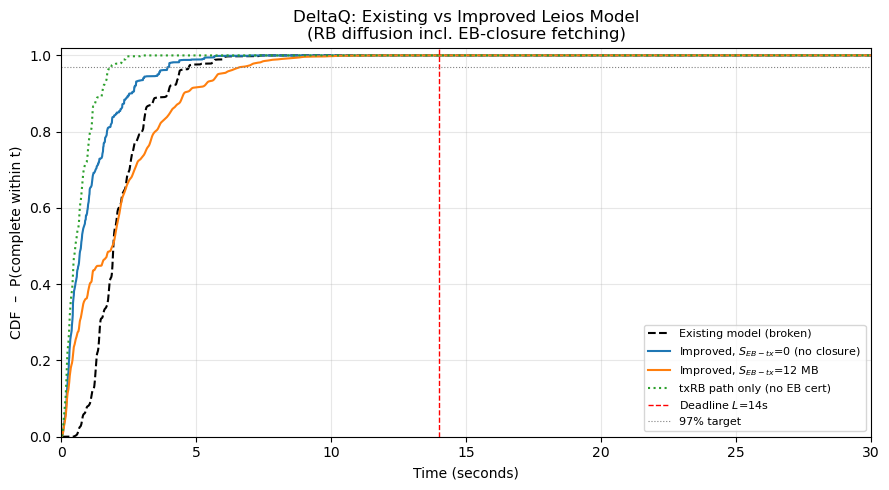

In [9]:
_N_SWEEP = 30
COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, _N_SWEEP))


def plot_cdf_comparison(ref_cdf, results):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(TIMES, ref_cdf, "k--", lw=1.5, label="Existing model (broken)")
    r0 = next(r for r in results if r["s_eb_tx_kb"] == 0)
    ax.plot(TIMES, r0["cdf_comb"], color="tab:blue", lw=1.5,
            label="Improved, $S_{EB-tx}$=0 (no closure)")
    r12 = next(r for r in results if r["s_eb_tx_kb"] == 12288)
    ax.plot(TIMES, r12["cdf_comb"], color="tab:orange", lw=1.5,
            label="Improved, $S_{EB-tx}$=12 MB")
    ax.plot(TIMES, r0["cdf_tx"], color="tab:green", lw=1.5, ls=":",
            label="txRB path only (no EB cert)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline $L$={int(L_DEADLINE)}s")
    ax.axhline(0.97, color="gray", ls=":", lw=0.8, label="97% target")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF  –  P(complete within t)")
    ax.set_title("DeltaQ: Existing vs Improved Leios Model\n"
                 "(RB diffusion incl. EB-closure fetching)")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim(0, 30); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_cdf_comparison(ref_cdf, results_mathis)


**`compare_models`**

**What it shows.** Four CDF curves plotted on the same axis, all representing
$P(\text{RB fully processed} \leq t)$:
- *Existing model (broken)* — replicates the prior Haskell analysis.
- *Improved, $S_{EB-tx}=0$* — improved model with no EB closure (baseline).
- *Improved, $S_{EB-tx}=12\,\text{MB}$* — improved model at the CIP target size.
- *txRB path only* — the non-cert branch (RB carries transactions, no EB).

The vertical dashed red line marks the 14-second deadline.

**Why it matters.** The prior model's CDF crosses the deadline at ~0.97,
which was used to validate the CIP parameters.  Under the new model both
the Mathis and CUBIC 12 MB CDFs plateau at $\approx 0.497$ — at the Praos
cap, no cliff.  The chart illustrates that the model corrections change
the interpretation fundamentally: what previously appeared to be a
feasibility limit at 0.974 is now revealed as the Praos 50% cap.

**Counterintuitive appearance — blue below orange.** The $S_{EB-tx}=0$ curve
(blue) sits *below* the $S_{EB-tx}=12\,\text{MB}$ curve (orange) at early
times, which looks backwards at first glance.  Both curves show the
*combined* round outcome:

$$\text{cdf\_comb}(t) = p_\text{cert} \times \text{certRB}(t) + (1-p_\text{cert}) \times \text{txRB}(t)$$

At $S_{EB-tx}=0$, $p_\text{cert} \approx 0.50$, so half of all rounds take the
certRB path, which requires fetching the EB body (up to 512 kB, blended
multi-hop) even when the closure is empty.  That diffusion overhead pulls the
$S_{EB-tx}=0$ curve below the $S_{EB-tx}=12\,\text{MB}$ curve at early times.

This is not an error.  It correctly reflects a real protocol cost: running
Linear Leios with active EB certification makes the average round *slower* than
pure Praos (txRB only), because cert rounds carry more network overhead.  The
green dotted *txRB path only* curve closely tracks the 12 MB curve, confirming
that the 12 MB result is dominated by the fast txRB path (50% of rounds).

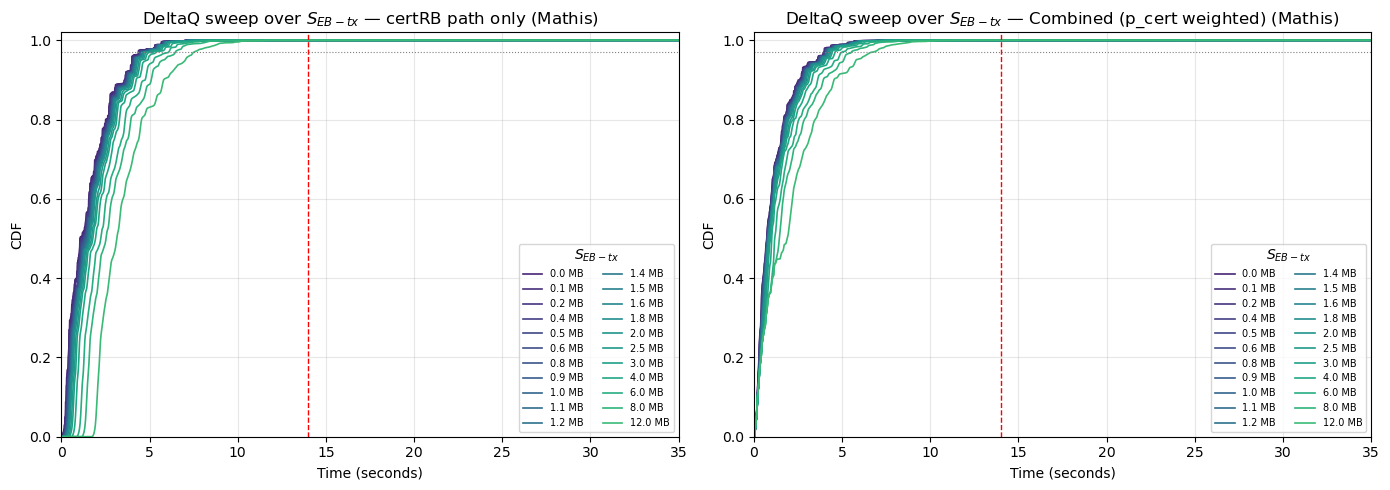

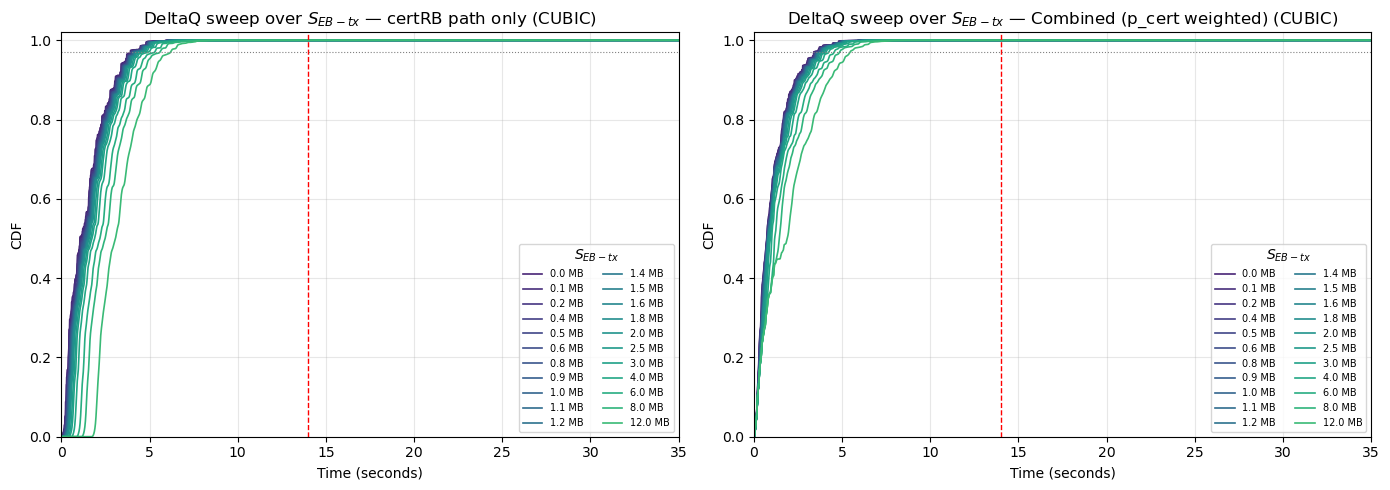

In [10]:
def plot_eb_closure_sweep(results, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1, ax2 = axes
    for i, r in enumerate(results):
        label = f"{r['s_eb_tx_kb']/1024:.1f} MB"
        ax1.plot(TIMES, r["cdf_cert"], color=COLORS[i], lw=1.2, label=label)
        ax2.plot(TIMES, r["cdf_comb"], color=COLORS[i], lw=1.2, label=label)
    for ax, title in [(ax1, "certRB path only"), (ax2, "Combined (p_cert weighted)")]:
        ax.axvline(L_DEADLINE, color="red", ls="--", lw=1)
        ax.axhline(0.97, color="gray", ls=":", lw=0.8)
        ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
        ax.set_title(f"DeltaQ sweep over $S_{{EB-tx}}$ — {title}{title_suffix}")
        ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
        ax.legend(loc="lower right", fontsize=7, title="$S_{EB-tx}$", ncol=2)
    fig.tight_layout(); plt.show()


plot_eb_closure_sweep(results_mathis, " (Mathis)")
plot_eb_closure_sweep(results_cubic, " (CUBIC)")


**`eb_closure_sweep`**

**What it shows.** A grid of CDF curves — one per simulated $S_{EB-tx}$ value
from 0 to 12 MB.  Two subplots cover (left) the certRB path CDF and (right)
the combined outcome CDF.  Curves are colour-coded by size; the vertical line
marks the 14-second deadline.

**Why it matters.** With the corrected per-tx constants and the corrected
Praos RTTs, every curve from 0 to 12 MB plateaus at $P_\text{cert} \approx
0.497$ before the 14-second deadline under both throughput models —
$P_\text{validating}$ is high enough at every CIP-target size that the
quorum is comfortably met.  No cliff appears in the plotted range under
either model.

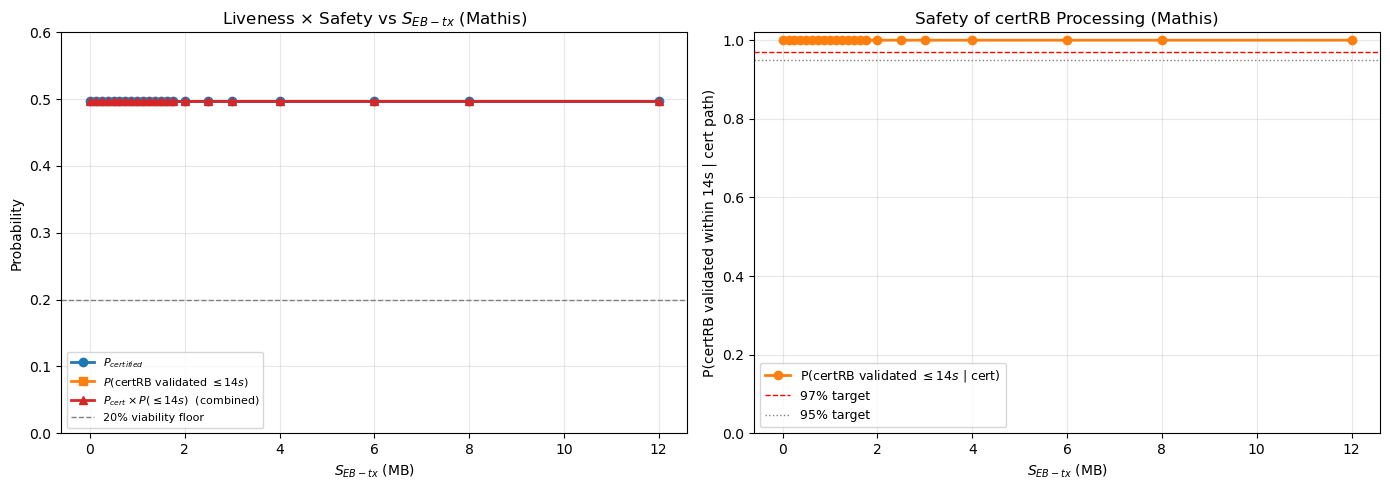

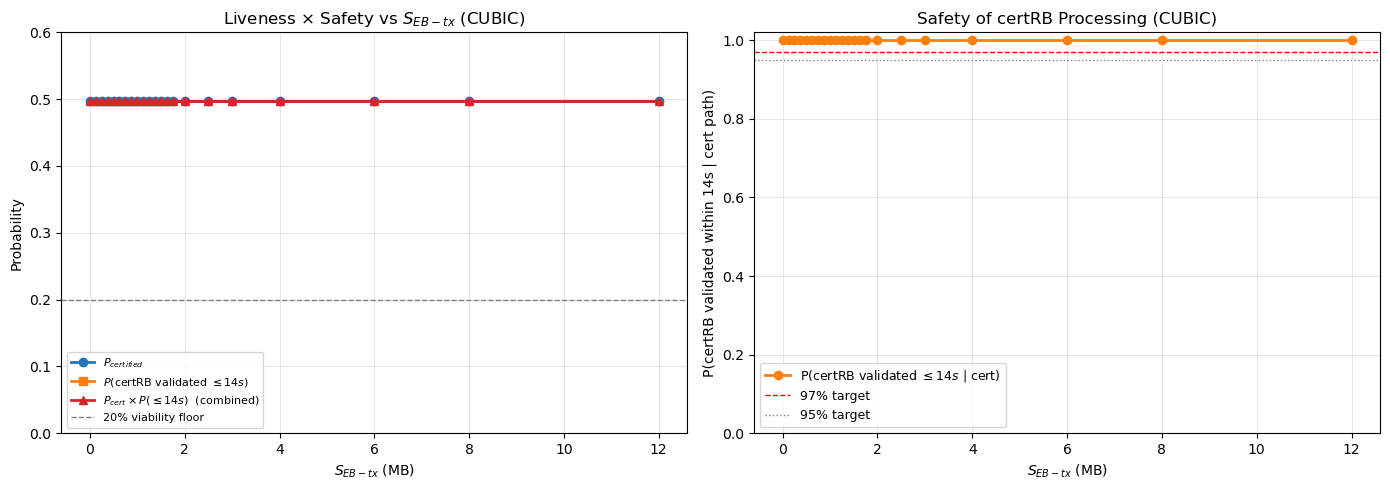

In [11]:
def plot_feasibility(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    sw_cert = [r["sw14_cert"] for r in results]
    p_c = [r["p_cert"] for r in results]
    cas = [r["p_cert_and_safe"] for r in results]
    ax1.plot(mbs, p_c, "o-", color="tab:blue", lw=2, label="$P_{certified}$")
    ax1.plot(mbs, sw_cert, "s-", color="tab:orange", lw=2,
             label="$P$(certRB validated $\\leq 14s$)")
    ax1.plot(mbs, cas, "^-", color="tab:red", lw=2,
             label="$P_{cert} \\times P(\\leq 14s)$  (combined)")
    ax1.axhline(0.20, color="gray", ls="--", lw=1, label="20% viability floor")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Liveness × Safety vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=8); ax1.set_ylim(0, 0.60); ax1.grid(True, alpha=0.3)

    ax2.plot(mbs, sw_cert, "o-", color="tab:orange", lw=2,
             label="P(certRB validated $\\leq 14s$ | cert)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.axhline(0.95, color="gray", ls=":", lw=1, label="95% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(certRB validated within 14s | cert path)")
    ax2.set_title(f"Safety of certRB Processing{title_suffix}")
    ax2.legend(fontsize=9); ax2.set_ylim(0, 1.02); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_feasibility(results_mathis, " (Mathis)")
plot_feasibility(results_cubic, " (CUBIC)")


**`feasibility`**

**What it shows.** Two subplots vs $S_{EB-tx}$:
- *Left* — three probability curves: $P_\text{cert}$ (liveness), $P(\text{certRB} \leq 14s)$ (safety), and their product $P_\text{cert} \times P(\leq 14s)$ (the combined outcome, the only quantity that matters for protocol correctness).
- *Right* — $P(\text{certRB validated} \leq 14s \mid \text{cert path})$ alone, zoomed to show whether the certRB diffusion time is a bottleneck.

**Why it matters.** Both panels stay essentially flat at $P_\text{cert}
\approx 0.497$ across the entire 0–12 MB range under either model.  The
"cert × safe" composite likewise stays at ≈ 0.497 throughout.  Confirms
the Praos cap is the only binding limit in the CIP target range — no
network-driven cliff appears under either model.

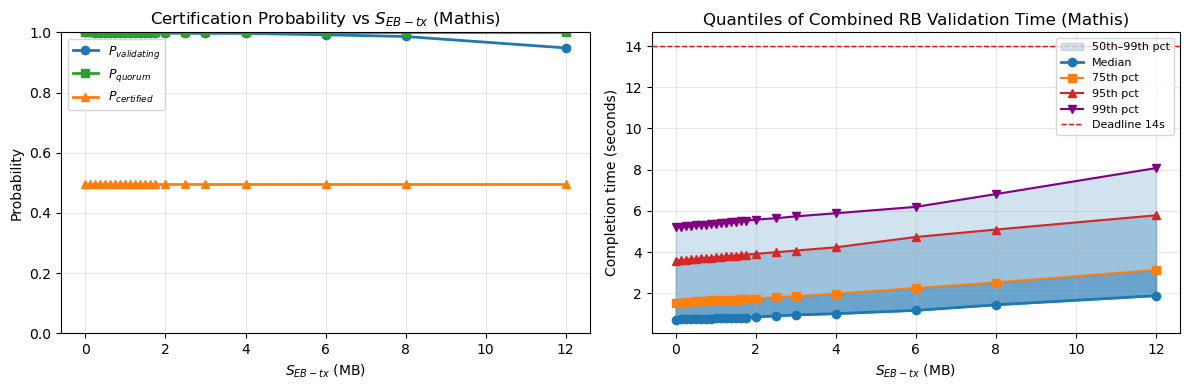

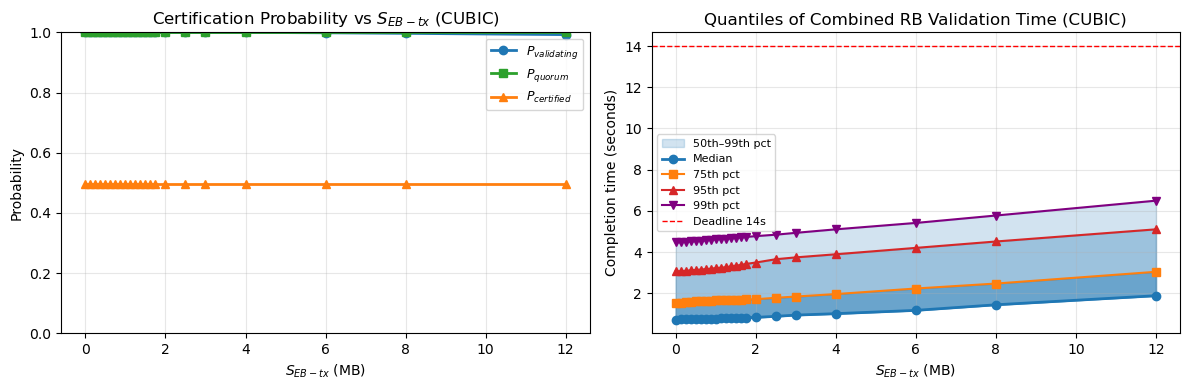

In [12]:
def plot_certification(results, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    mbs = [r["s_eb_tx_kb"] / 1024 for r in results]
    p_v = [r["p_validating"] for r in results]
    p_q = [r["p_quorum"] for r in results]
    p_c = [r["p_cert"] for r in results]
    ax1.plot(mbs, p_v, "o-", color="tab:blue", lw=2, label="$P_{validating}$")
    ax1.plot(mbs, p_q, "s-", color="tab:green", lw=2, label="$P_{quorum}$")
    ax1.plot(mbs, p_c, "^-", color="tab:orange", lw=2, label="$P_{certified}$")
    ax1.set_xlabel("$S_{EB-tx}$ (MB)"); ax1.set_ylabel("Probability")
    ax1.set_title(f"Certification Probability vs $S_{{EB-tx}}${title_suffix}")
    ax1.legend(fontsize=9); ax1.set_ylim(0, 1.0); ax1.grid(True, alpha=0.3)

    q50 = [r["q50"] for r in results]
    q75 = [r["q75"] for r in results]
    q95 = [r["q95"] for r in results]
    q99 = [r["q99"] for r in results]
    ax2.fill_between(mbs, q50, q99, alpha=0.2, color="tab:blue", label="50th–99th pct")
    ax2.fill_between(mbs, q50, q95, alpha=0.3, color="tab:blue")
    ax2.fill_between(mbs, q50, q75, alpha=0.4, color="tab:blue")
    ax2.plot(mbs, q50, "o-", color="tab:blue", lw=2, label="Median")
    ax2.plot(mbs, q75, "s-", color="tab:orange", lw=1.5, label="75th pct")
    ax2.plot(mbs, q95, "^-", color="tab:red", lw=1.5, label="95th pct")
    ax2.plot(mbs, q99, "v-", color="purple", lw=1.5, label="99th pct")
    ax2.axhline(L_DEADLINE, color="red", ls="--", lw=1, label=f"Deadline {int(L_DEADLINE)}s")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)"); ax2.set_ylabel("Completion time (seconds)")
    ax2.set_title(f"Quantiles of Combined RB Validation Time{title_suffix}")
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


plot_certification(results_mathis, " (Mathis)")
plot_certification(results_cubic, " (CUBIC)")


**`certification`**

**What it shows.** Two subplots vs $S_{EB-tx}$:
- *Left* — the three components of $P_\text{cert}$: $P_\text{validating}$
  (voter pipeline ≤ 7s), $P_\text{quorum}$ (≥ 450 votes collected), and
  $P_\text{cert}$ itself.  $P_\text{interrupted}$ (≈ 0.503) is a constant cap
  annotated as a horizontal band.
- *Right* — quantiles (Q50, Q75, Q95) of the certRB completion time vs
  $S_{EB-tx}$, showing how the tail of the distribution shifts.

**Why it matters.**
- *Mathis*: $P_\text{validating}$ declines from ≈ 1.000 at 0 MB to 0.948 at
  12 MB — always well above the 0.75 quorum threshold.  $P_\text{quorum}
  \approx 1.0$ throughout; $P_\text{cert}$ stays at the Praos cap.
- *CUBIC*: $P_\text{validating}$ declines from ≈ 1.000 at 0 MB to 0.992 at
  12 MB.  Same conclusion: $P_\text{cert}$ at the Praos cap.

The right panel (Q50/Q75/Q95 quantiles) shows slowly increasing tails as
closure size grows in both models, driven by the longer voter pipeline.

### 5.2 Network Diffusion of the EB Closure

With CPU no longer the binding constraint, network diffusion is the primary
bottleneck.  Two scenarios:

- **1-hop approximation** (voter path in §5.1): each cache-miss node fetches
  only the missing fraction ($\pi_1 \cdot S_{EB-tx}$) from its upstream peer.
- **Full blended diffusion** (worst case — transactions not pre-diffused):
  the entire $S_{EB-tx}$ traverses the blended multi-hop network.


In [13]:
def run_network_diffusion():
    """
    Compute network-only diffusion time for the EB closure under two models:
      (a) 1-hop approximation: node fetches only the missing fraction (π₁·S_EB_tx)
          from its upstream peer (one hop).  Justified if the raw transactions
          referenced by the EB have already diffused via tx-submission before
          the EB is produced.  (Linear Leios has no Input Blocks; transactions
          diffuse solely via tx-submission.)
      (b) Full blended diffusion: the entire S_EB_tx must traverse the blended
          multi-hop network (worst case: transactions not pre-diffused).

    CPU reapplication is NOT included – this isolates the network constraint.
    """
    sweep_kb = [512, 1024, 1536, 2048, 4096, 8192, 12288]

    rows = []
    for s_kb in sweep_kb:
        miss_kb = TX_CACHE_MISS_RATE * s_kb  # π₁ · S_EB_tx

        # (a) 1-hop for missing fraction
        net_1hop = cdf_sequential(cdf_fetch_eb_body(), cdf_hop(miss_kb))
        # (b) blended multi-hop for missing fraction
        net_miss_blended = cdf_sequential(
            cdf_fetch_eb_body(), cdf_blended_delay(miss_kb)
        )
        # (c) full closure blended (no 1-hop shortcut)
        net_full_blended = cdf_blended_delay(s_kb)

        rows.append(
            dict(
                s_kb=s_kb,
                net_1hop=net_1hop,
                net_miss_blend=net_miss_blended,
                net_full_blend=net_full_blended,
                sw7_1hop=success_within(net_1hop, 7.0),
                sw7_miss_blend=success_within(net_miss_blended, 7.0),
                sw14_full=success_within(net_full_blended, 14.0),
                sw7_full=success_within(net_full_blended, 7.0),
            )
        )
    return rows


/tmp/nix-shell.2ZbfTL/ipykernel_393222/1540215392.py:25: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "v-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",


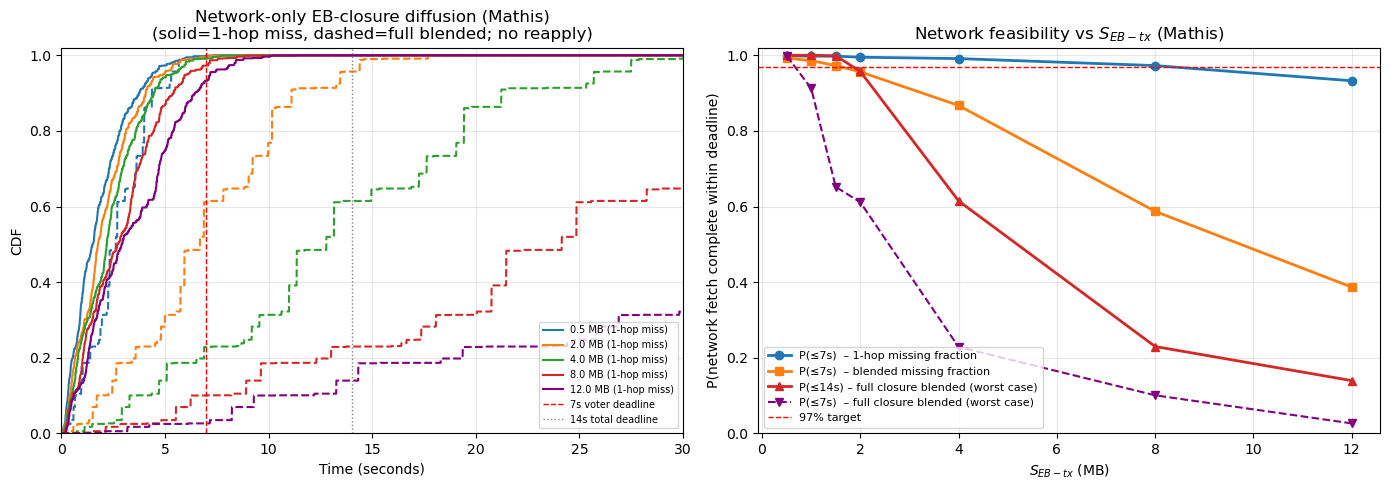

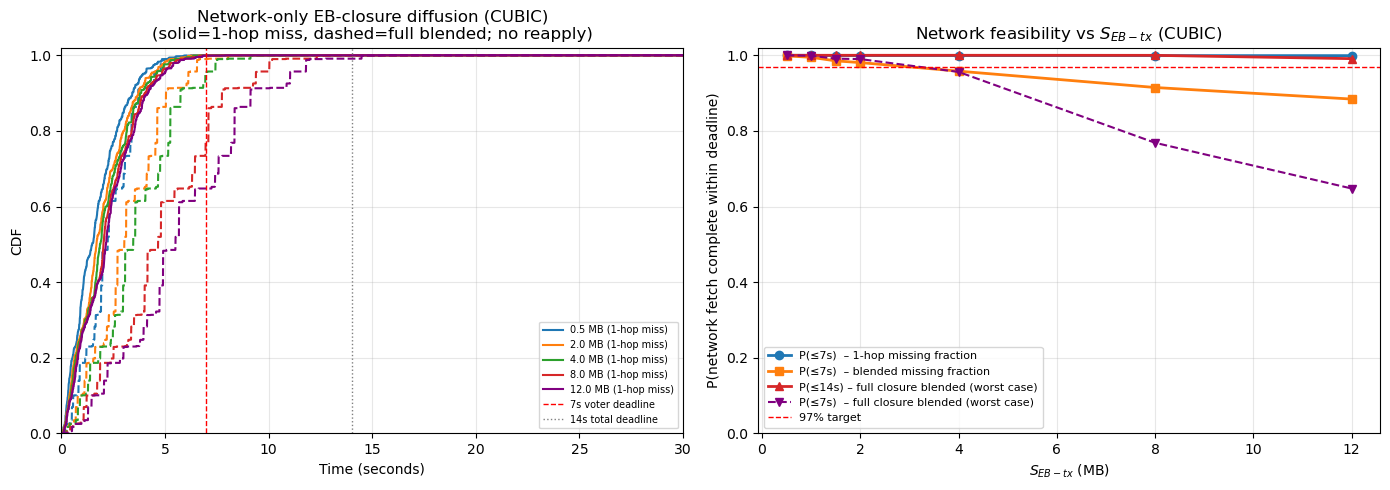

In [14]:
def plot_network_diffusion(rows, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    highlight = [512, 2048, 4096, 8192, 12288]
    colors_h = ["tab:blue", "tab:orange", "tab:green", "tab:red", "purple"]
    for row, col in zip([r for r in rows if r["s_kb"] in highlight], colors_h):
        lbl = f"{row['s_kb']/1024:.1f} MB"
        ax1.plot(TIMES, row["net_1hop"], color=col, lw=1.5, ls="-",
                 label=f"{lbl} (1-hop miss)")
        ax1.plot(TIMES, row["net_full_blend"], color=col, lw=1.5, ls="--")
    ax1.axvline(7.0, color="red", ls="--", lw=1, label="7s voter deadline")
    ax1.axvline(14.0, color="gray", ls=":", lw=1, label="14s total deadline")
    ax1.set_xlabel("Time (seconds)"); ax1.set_ylabel("CDF")
    ax1.set_title(f"Network-only EB-closure diffusion{title_suffix}\n"
                 "(solid=1-hop miss, dashed=full blended; no reapply)")
    ax1.legend(fontsize=7, loc="lower right")
    ax1.set_xlim(0, 30); ax1.set_ylim(0, 1.02); ax1.grid(True, alpha=0.3)

    mbs = [r["s_kb"] / 1024 for r in rows]
    ax2.plot(mbs, [r["sw7_1hop"] for r in rows], "o-", color="tab:blue", lw=2,
             label="P(≤7s)  – 1-hop missing fraction")
    ax2.plot(mbs, [r["sw7_miss_blend"] for r in rows], "s-", color="tab:orange",
             lw=2, label="P(≤7s)  – blended missing fraction")
    ax2.plot(mbs, [r["sw14_full"] for r in rows], "^-", color="tab:red",
             lw=2, label="P(≤14s) – full closure blended (worst case)")
    ax2.plot(mbs, [r["sw7_full"] for r in rows], "v-", color="purple",
             lw=1.5, ls="--", label="P(≤7s)  – full closure blended (worst case)")
    ax2.axhline(0.97, color="red", ls="--", lw=1, label="97% target")
    ax2.set_xlabel("$S_{EB-tx}$ (MB)")
    ax2.set_ylabel("P(network fetch complete within deadline)")
    ax2.set_title(f"Network feasibility vs $S_{{EB-tx}}${title_suffix}")
    ax2.legend(fontsize=8, loc="lower left"); ax2.set_ylim(0, 1.02)
    ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()


set_network_model("mathis"); net_mathis = run_network_diffusion()
plot_network_diffusion(net_mathis, " (Mathis)")

set_network_model("cubic"); net_cubic = run_network_diffusion()
plot_network_diffusion(net_cubic, " (CUBIC)")


**`network_diffusion`**

**What it shows.** A network-only (CPU excluded) analysis across $S_{EB-tx}$
values from 0.5 MB to 12 MB.  Three $P(\leq t)$ curves are shown for each
size: 1-hop fetch of missing fraction (EB body + 1-hop), blended fetch of
missing fraction (EB body + blended multi-hop), and full blended diffusion of
the entire closure.  The 7-second voter deadline and 14-second total deadline
are annotated.

**Why it matters.** This plot answers the question "even if the CPU were
infinitely fast, could the network deliver the closure in time?"  All
three curves assume *every* voter must fetch (i.e. treat all voters as
cache-miss); this is therefore strictly more conservative than the
§5.1 voter pipeline, where 5/6 of voters are cache-hits with a near-zero
lookup.
- *Mathis*: full-blended at 12 MB gives $P(\leq 14\,\text{s}) = 0.139$ —
  the network delivers only 14% of the time under the worst-case
  no-pre-diffusion assumption.  The 1-hop scenario at 12 MB gives
  $P(\leq 7\,\text{s}) \approx 0.933$ (essentially feasible).
- *CUBIC*: full-blended at 12 MB gives $P(\leq 14\,\text{s}) = 0.991$ —
  essentially feasible even without pre-diffusion.  1-hop at 12 MB gives
  $P(\leq 7\,\text{s}) \approx 0.999$.

The 1-hop scenario is feasible under either model at every CIP-target
size.  The full-blended worst case still distinguishes the models —
Mathis fails, CUBIC succeeds on the network delivery alone — but the
voter pipeline plus quorum threshold still makes the full-blended case
effectively infeasible under both models (see §5.3 "Full-blended worst
case").

### 5.3 Sensitivity: 1-hop vs Multi-hop EB Closure Fetch

For every CIP-target size up to 12 MB, the 1-hop and blended-missing
multi-hop models both give $P_\text{cert}$ at the Praos cap $\approx 0.497$
under either throughput model — the missing-closure fetch
($\pi_1 \cdot S$, up to 2 MB at 12 MB for $\pi_1 = 1/6$) is small enough to
complete in time even over multi-hop paths.

The cell below reproduces the per-model CDF comparison at $S_{EB-tx}$ = 12 MB.


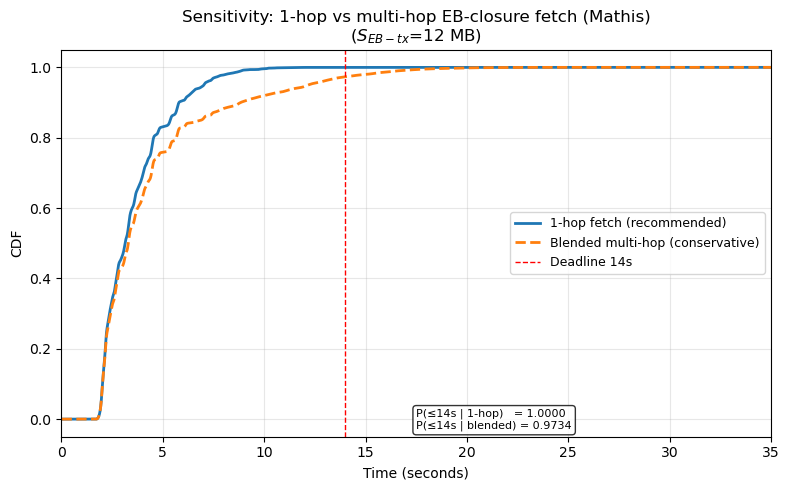

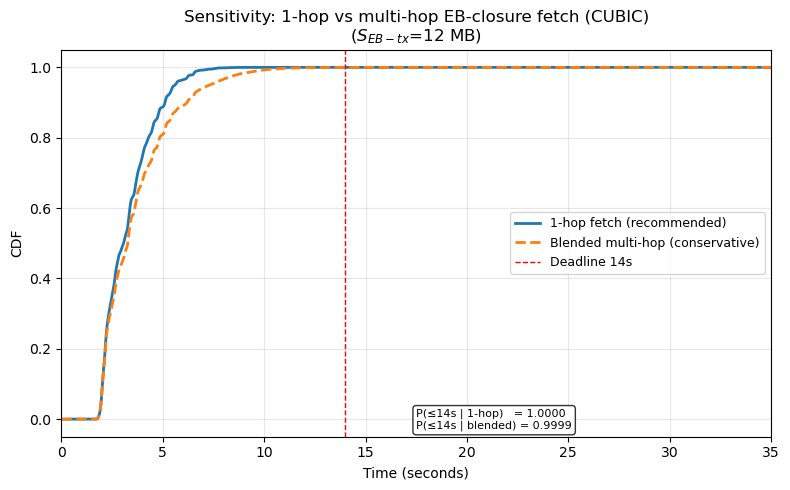

Mathis: {'1hop_sw14': 0.9999984110653871, 'blended_sw14': 0.9734374657658753}
CUBIC : {'1hop_sw14': 0.9999999999999989, 'blended_sw14': 0.9999449394092494}


In [15]:
def sensitivity_1hop_vs_blended(title_suffix=""):
    s_kb = 12288  # === edit: switch to a smaller closure to see the gap shrink ===
    cert_1hop = cdf_process_cert_rb(s_kb)

    eb_body = cdf_fetch_eb_body()
    cert_rb = cdf_fetch_cert_rb_body()
    missing_kb = TX_CACHE_MISS_RATE * s_kb
    miss_blended = cdf_choice(TX_CACHE_HIT_RATE, cdf_wait(0.001),
                              cdf_blended_delay(missing_kb))
    eb_blended = cdf_sequential(eb_body, miss_blended)
    parallel_b = cdf_last_to_finish(cert_rb, eb_blended)
    cert_blended = cdf_sequential(parallel_b, reapply_txs_cdf(s_kb))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(TIMES, cert_1hop, lw=2, label="1-hop fetch (recommended)")
    ax.plot(TIMES, cert_blended, lw=2, ls="--",
            label="Blended multi-hop (conservative)")
    ax.axvline(L_DEADLINE, color="red", ls="--", lw=1,
               label=f"Deadline {int(L_DEADLINE)}s")
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(f"Sensitivity: 1-hop vs multi-hop EB-closure fetch{title_suffix}\n"
                 f"($S_{{EB-tx}}$={s_kb/1024:.0f} MB)")
    ax.legend(fontsize=9); ax.set_xlim(0, 35); ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.02,
            f"P(≤14s | 1-hop)   = {success_within(cert_1hop,14):.4f}\n"
            f"P(≤14s | blended) = {success_within(cert_blended,14):.4f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    fig.tight_layout(); plt.show()
    return {"1hop_sw14": success_within(cert_1hop, 14.0),
            "blended_sw14": success_within(cert_blended, 14.0)}


set_network_model("mathis"); sens_mathis = sensitivity_1hop_vs_blended(" (Mathis)")
set_network_model("cubic"); sens_cubic = sensitivity_1hop_vs_blended(" (CUBIC)")
print("Mathis:", sens_mathis); print("CUBIC :", sens_cubic)


**`sensitivity_1hop_vs_blended`**

**What it shows.** CDF curves for the full certRB-path pipeline at
$S_{EB-tx} = 12\,\text{MB}$, under two assumptions about how missing
transactions are fetched:
- *1-hop* — each node fetches only the missing fraction ($\pi_1 \cdot S$)
  from its upstream peer (1 network hop).
- *Blended* — missing transactions must traverse the full blended multi-hop
  network model.

**Why it matters.**
- *Mathis*: 1-hop and blended both give $P_\text{cert} = 0.497$ (Praos
  cap).  $P_\text{validating}$ drops from 0.948 (1-hop) to 0.854
  (blended) but stays above the quorum threshold.
- *CUBIC*: 1-hop and blended both give $P_\text{cert} = 0.497$.
  $P_\text{validating}$ drops from 0.992 (1-hop) to 0.942 (blended).

The 1-hop vs blended-missing distinction is not feasibility-relevant in
the 0–12 MB range: both pathways succeed.  The plot confirms the
small-but-real $P_\text{validating}$ gap between 1-hop and blended
without it changing the certification outcome.

### 5.4 Network Model Sensitivity (Mathis vs CUBIC vs loss rate)

Quantify how each throughput model responds to packet loss $p$, and where the
2 MB long-haul fetch crosses the 7 s voter deadline.

| Throughput model | $p$ at which 2 MB long-haul = 7 s |
|------------------|-----------------------------------|
| Mathis           | $\approx 2.8 \times 10^{-4}$      |
| CUBIC            | $\approx 4.6 \times 10^{-3}$      |

The analysis default $p = 10^{-4}$ lies well below both crossings.


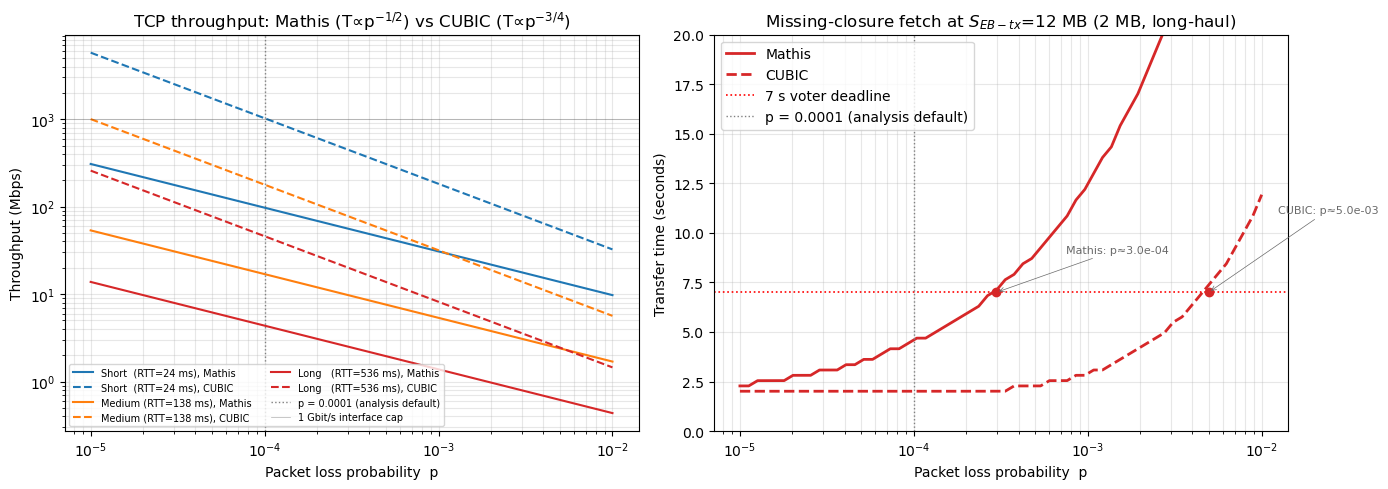

In [16]:
def plot_network_model_comparison():
    p_grid = np.logspace(-5, -2, 60)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    distances = [
        ("Short  (RTT=24 ms)",  _OWD_SHORT_S, "tab:blue"),
        ("Medium (RTT=138 ms)", _OWD_MED_S,   "tab:orange"),
        ("Long   (RTT=536 ms)", _OWD_LONG_S,  "tab:red"),
    ]
    for label, owd, color in distances:
        rtt = 2.0 * owd
        T_m = np.array([_steady_state_window("mathis", p) / rtt * 8 / 1e6 for p in p_grid])
        T_c = np.array([_steady_state_window("cubic", p)  / rtt * 8 / 1e6 for p in p_grid])
        ax1.loglog(p_grid, T_m, "-",  color=color, lw=1.5, label=f"{label}, Mathis")
        ax1.loglog(p_grid, T_c, "--", color=color, lw=1.5, label=f"{label}, CUBIC")
    ax1.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    ax1.axhline(1e3, color="black", ls="-", lw=0.5, alpha=0.3,
                label="1 Gbit/s interface cap")
    ax1.set_xlabel("Packet loss probability  p"); ax1.set_ylabel("Throughput (Mbps)")
    ax1.set_title("TCP throughput: Mathis (T∝p$^{-1/2}$) vs CUBIC (T∝p$^{-3/4}$)")
    ax1.grid(alpha=0.3, which="both"); ax1.legend(fontsize=7, loc="lower left", ncol=2)

    t_m = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "mathis", p) for p in p_grid])
    t_c = np.array([_tcp_transfer_time(2048, _OWD_LONG_S, "cubic", p)  for p in p_grid])
    ax2.semilogx(p_grid, t_m, "-",  color="tab:red", lw=2, label="Mathis")
    ax2.semilogx(p_grid, t_c, "--", color="tab:red", lw=2, label="CUBIC")
    ax2.axhline(7.0, color="red", ls=":", lw=1.2, label="7 s voter deadline")
    ax2.axvline(_TCP_LOSS, color="gray", ls=":", lw=1,
                label=f"p = {_TCP_LOSS:g} (analysis default)")
    for arr, name in [(t_m, "Mathis"), (t_c, "CUBIC")]:
        idx = int(np.searchsorted(arr, 7.0))
        if 0 < idx < len(p_grid):
            ax2.plot(p_grid[idx], 7.0, "o", color="tab:red", ms=6)
            ax2.annotate(f"{name}: p≈{p_grid[idx]:.1e}",
                         xy=(p_grid[idx], 7.0),
                         xytext=(p_grid[idx]*2.5, 9 if name=="Mathis" else 11),
                         fontsize=8, color="dimgray",
                         arrowprops=dict(arrowstyle="->", color="dimgray", lw=0.5))
    ax2.set_ylim(0, 20)
    ax2.set_xlabel("Packet loss probability  p"); ax2.set_ylabel("Transfer time (seconds)")
    ax2.set_title("Missing-closure fetch at $S_{EB-tx}$=12 MB (2 MB, long-haul)")
    ax2.grid(alpha=0.3, which="both"); ax2.legend(loc="upper left")
    fig.tight_layout(); plt.show()


plot_network_model_comparison()


**`network_model_comparison` *(top-level, both models)***

**What it shows.** Two panels, side by side:
- *Left* — steady-state TCP throughput vs packet-loss probability $p$, plotted
  on log–log axes for each of the three distance categories under both Mathis
  ($T \propto p^{-1/2}$, solid) and CUBIC ($T \propto p^{-3/4}$, dashed).
  The 1 Gbit/s interface cap and the analysis default $p = 10^{-4}$ are marked.
- *Right* — transfer time for a 2 MB long-haul (OWD = 268 ms) fetch vs $p$
  (semilog), with the 7 s voter deadline marked.  This is the
  missing-closure load at $S_{EB-tx} = 12$ MB.  Annotation arrows show
  approximately where each model crosses the deadline.

**Why it matters.** Quantifies how much loss-rate headroom each model has
before hitting the 7 s deadline.  The 2 MB fetch hits the 7 s deadline at
$p \approx 2.8 \times 10^{-4}$ under Mathis and $\approx 4.6 \times 10^{-3}$
under CUBIC — both *above* the analysis default of $10^{-4}$, so the
12 MB cliff is absent under either model at default $p$.  Mathis tolerates
~2.8× higher loss before falling off the cliff; CUBIC tolerates ~46×.

### 5.5 TxCache Miss Rate Sensitivity (π₁ sweep)

The default cache miss rate $\pi_1 = 1/6 \approx 0.17$ is inherited from the
prior Haskell ΔQ model.  An empirical extraction from
`post-cip/mempool-measurements/` (see `pi1_derivation.ipynb`) gives:

| Source | $\pi_1$ |
|--------|---------|
| Prior model (hand-chosen Markov) | **0.167** |
| Empirical mean (cross-region BAU) | **0.06** |
| Empirical worst-case pair | **0.085** |
| Empirical range | [0.02, 0.09] |

The prior value is ~3× the empirical mean.  The sweep below confirms the
12 MB target is feasible under every $\pi_1 \leq 1/6$ in both models, with
sensitivity emerging only at $\pi_1 \geq 0.50$ under Mathis.


In [17]:
PI1_SWEEP_VALUES = (0.05, 0.10, 1.0 / 6.0, 0.30, 0.50)


def run_pi1_sensitivity(pi1_values=PI1_SWEEP_VALUES):
    """
    For each (network model × π₁) combination, run the full S_EB_tx sweep
    and collect P_validating, P_cert and the safety probability.

    Returns: { model_label: { pi1: [results_dict, ...], ... }, ... }
    """
    # Cache the active state so we can restore it on exit.
    saved_model = NETWORK_MODEL
    saved_pi1 = TX_CACHE_MISS_RATE

    out = {}
    for model in ("mathis", "cubic"):
        set_network_model(model)
        out[model] = {}
        for pi1 in pi1_values:
            set_cache_miss_rate(pi1)
            print(
                f"  [π₁ sensitivity] model={model:6s}  π₁={pi1:.4f}  ...",
                end="",
                flush=True,
            )
            out[model][pi1] = run_sweep()
            r12 = next(
                (r for r in out[model][pi1] if abs(r["s_eb_tx_kb"] - 12288) < 1), None
            )
            if r12:
                print(f"  P_cert@12MB = {r12['p_cert']:.4f}")
            else:
                print()

    set_network_model(saved_model)
    set_cache_miss_rate(saved_pi1)
    return out

def print_pi1_sensitivity_summary(sens):
    """Console table: P_cert @ S_EB_tx ∈ {1, 4, 8, 12 MB} for each model × π₁."""
    print("\n" + "=" * 78)
    print("π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)")
    print("=" * 78)
    sizes_kb = [1024, 4096, 8192, 12288]
    for model in ("mathis", "cubic"):
        print(f"\n[{model.upper()}]")
        header = f"  {'π₁':>6}  " + "  ".join(f"{s/1024:>4.0f}MB" for s in sizes_kb)
        print(header)
        print("  " + "-" * (len(header) - 2))
        for pi1, rs in sorted(sens[model].items()):
            cells = []
            for s_kb in sizes_kb:
                r = next((x for x in rs if abs(x["s_eb_tx_kb"] - s_kb) < 1), None)
                cells.append(f"{r['p_cert']:.3f}" if r else "  —")
            tag = "1/6" if abs(pi1 - 1 / 6) < 1e-4 else f"{pi1:.3f}"
            print(f"  {tag:>6}  " + "  ".join(f"{c:>6s}" for c in cells))


  [π₁ sensitivity] model=mathis  π₁=0.0500  ...   S_EB_tx  p_valid  p_quorum   p_cert  sw14|cert  p_cert×safe     Q50     Q75     Q95     Q99
----------------------------------------------------------------------------------------------
  0.000 MB   0.9997    1.0000   0.4966     1.0000       0.4966    0.73    1.55    3.56    5.23
  0.125 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.55    3.57    5.24
  0.250 MB   0.9996    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.59    5.25
  0.375 MB   0.9992    1.0000   0.4966     1.0000       0.4966    0.74    1.56    3.60    5.26
  0.500 MB   0.9980    1.0000   0.4966     1.0000       0.4966    0.74    1.57    3.61    5.27
  0.625 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.58    3.63    5.28
  0.750 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.59    3.64    5.30
  0.875 MB   0.9978    1.0000   0.4966     1.0000       0.4966    0.75    1.60    3.65    5.31
  1

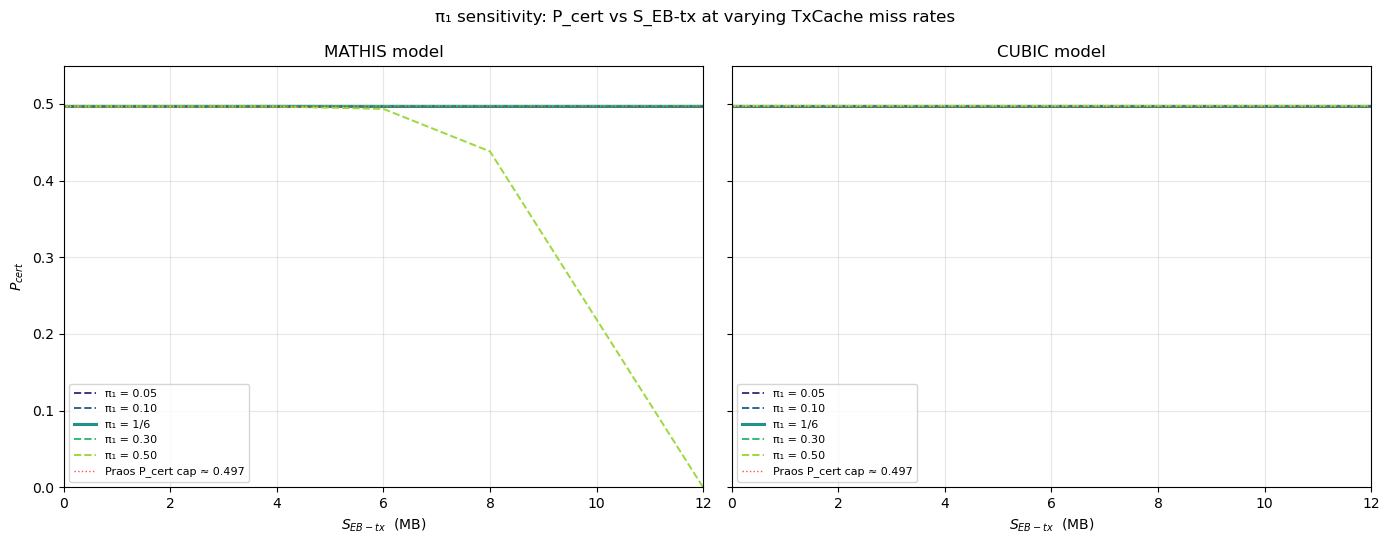


π₁ SENSITIVITY — P_cert at selected S_EB_tx (per model)

[MATHIS]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.438   0.000

[CUBIC]
      π₁     1MB     4MB     8MB    12MB
  --------------------------------------
   0.050   0.497   0.497   0.497   0.497
   0.100   0.497   0.497   0.497   0.497
     1/6   0.497   0.497   0.497   0.497
   0.300   0.497   0.497   0.497   0.497
   0.500   0.497   0.497   0.497   0.497


In [18]:
def plot_pi1_sensitivity(sens):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    pi1_values = sorted(next(iter(sens.values())).keys())
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(pi1_values)))
    for ax, model in zip(axes, ("mathis", "cubic")):
        for pi1, color in zip(pi1_values, cmap):
            rs = sens[model][pi1]
            mbs = [r["s_eb_tx_kb"]/1024 for r in rs]
            pcs = [r["p_cert"] for r in rs]
            tag = "1/6" if abs(pi1 - 1/6) < 1e-4 else f"{pi1:.2f}"
            lw = 2.2 if abs(pi1 - 1/6) < 1e-4 else 1.4
            ls = "-"  if abs(pi1 - 1/6) < 1e-4 else "--"
            ax.plot(mbs, pcs, ls, color=color, lw=lw, label=f"π₁ = {tag}")
        ax.axhline(0.497, color="red", ls=":", lw=1, alpha=0.7,
                   label="Praos P_cert cap ≈ 0.497")
        ax.set_xlabel("$S_{EB-tx}$  (MB)"); ax.set_title(f"{model.upper()} model")
        ax.set_xlim(0, 12); ax.set_ylim(0, 0.55); ax.grid(alpha=0.3)
        ax.legend(loc="lower left", fontsize=8)
    axes[0].set_ylabel("$P_{cert}$")
    fig.suptitle("π₁ sensitivity: P_cert vs S_EB-tx at varying TxCache miss rates",
                 fontsize=12)
    fig.tight_layout(); plt.show()


pi1_sens = run_pi1_sensitivity()
plot_pi1_sensitivity(pi1_sens)
print_pi1_sensitivity_summary(pi1_sens)


**`pi1_sensitivity` *(top-level, both models)***

**What it shows.** Two side-by-side panels (Mathis | CUBIC).  In each panel,
$P_\text{cert}$ vs $S_{EB-tx}$ is plotted as a family of curves, one per
TxCache miss rate $\pi_1 \in \{0.05,\, 0.10,\, 1/6,\, 0.30,\, 0.50\}$.  The
default $\pi_1 = 1/6$ curve is highlighted (thicker, solid); others are
dashed.  The horizontal red dotted line marks the Praos cap
$P_\text{cert} \approx 0.497$.

**Why it matters.** Shows how the quorum cliff (or lack thereof) shifts
with the assumed mempool-fragmentation rate.  **No cliff appears in the
0–12 MB range at any $\pi_1 \leq 1/6$** under either model.  The cliff
only appears for Mathis at $\pi_1 = 0.50$; CUBIC remains feasible at
every tested $\pi_1$ across the full sweep.

### 5.6 Full Closure Diffusion Conditional on Certification

Security Assumption 1 (Panagiotakos report) requires that a certified EB
reaches **all** honest nodes by the end of $L_\text{diff}$.  For a node to
actually *act* on the EB it must hold and re-validate the entire **EB closure**
— the body **plus** all referenced transactions — so "reaches a node" means the
node has completed the full closure pipeline, not merely received the body.  We
therefore compute the conditional CDF

$$F_{\text{full}\mid C}(t)\;:=\;P\!\left(\max_{j=1\ldots N} T_j \le t \;\bigg|\; C\right)$$

where $T_j$ is the **EB-closure completion time** at node $j$ and $C$ is the
certification event "the on-time committee votes carry at least a fraction
$\tau$ of the **total active stake** (the CIP-0164 quorum) by
$t_v = 3L_\text{hdr}+L_\text{vote}=7\,\text{s}$".

#### The closure-completion CDF $G$

Unlike the body, the closure is not delivered in one transfer: a node must
receive the EB body, fetch the *missing* fraction $\pi_1\cdot S_{EB\text{-}tx}$
of referenced transactions, and re-apply the whole closure.  The per-node
arrival law is therefore the **sequential composition** of stages defined in §4,

$$G\;=\;\underbrace{\texttt{cdf\_fetch\_eb\_body()}}_{\text{body diffusion}}\;\otimes\;\underbrace{\texttt{cdf\_fetch\_missing\_eb\_closure}(S_{EB\text{-}tx})}_{\text{fetch missing txs (1-hop)}}\;\otimes\;\underbrace{\texttt{reapply\_txs\_cdf}(S_{EB\text{-}tx})}_{\text{re-validate closure (CPU)}}$$

where $\otimes$ is sequential convolution (`cdf_sequential`).  The first two
stages alone give a *delivery-only* variant (`include_validation=False`);
including the re-apply stage gives the *readiness* variant — exactly
`cdf_validate_eb_for_voter` — and the model is parameterised by the closure
size $S_{EB\text{-}tx}$.  Using $G(t_v)$ for the voter half is also
*self-consistent*: a committee member can only vote once it has validated the
closure, so $G(t_v)$ is the genuine per-voter certification probability.

#### Stake-weighted committee  *(the threshold is on stake, not node count)*

Certification is **stake-weighted**: by CIP-0164 an EB is certified once the
on-time votes carry at least a fraction $\tau$ of the **total active stake**,

$$\sum_{v\in\text{votes}}\text{stake}(v)\;\ge\;\theta,\qquad
\theta:=\tau\cdot S_\text{active},$$

where $S_\text{active}$ is the total active stake.  The committee is the
**canonical CIP-0164 voting committee**: a *deterministic* stake-based truncation
— order SPOs by active stake (descending) and select until their cumulative stake
reaches the target $\sigma_c$ (`stake_cover`; equivalently the truncation error
falls below $\varepsilon_c=1-\sigma_c$).  The set is **fixed for the epoch — no
sortition, no per-EB lottery**.  Each member of the committee votes with weight
$w_i=s_i$.  Because the
committee holds only a fraction $\sigma_c$ of the total stake,
$S_\text{active}=M/\sigma_c$ and the quorum is $\theta=\tau\,M/\sigma_c$ — the
committee must contribute $\tau/\sigma_c$ of *its own* weight (certification is
impossible if $\tau>\sigma_c$).

Because per-node closure completion $T_i$ is assumed independent of stake,
committee membership only fixes *which* nodes vote (and with what weight); each
node's completion law is still $G$.  Writing the on-time vote total, when every
committee member is independently on time with probability $p$, as a weighted sum
**over the committee**

$$V(p)\;=\;\sum_{i\in\text{cmte}} w_i\,\text{Bern}(p),\qquad
\mathbb{E}[V(p)] = M p,\qquad
\operatorname{Var}[V(p)] = M_2\,p(1-p),$$

with the committee weight and its second moment

$$M=\sum_{i\in\text{cmte}} w_i=\sum_{i\in\text{cmte}} s_i,\qquad
M_2=\sum_{i\in\text{cmte}} w_i^2=\sum_{i\in\text{cmte}} s_i^2,$$

gives a **weighted Binomial** — all committee members share the same on-time
probability $p$, so there is **no election variance** (the committee is fixed; the
only randomness is each member's on-time indicator).  (The shared
`_committee_moments` returns $(M,\,M_2,\,S_\text{active})$.)  We use the §4.5 Normal approximation for the upper
tail (Step 7) and define the **stake-weighted quorum function**

$$Q(p)\;:=\;P\!\bigl(V(p)\ge \theta\bigr),$$

the probability that the on-time votes meet the quorum $\theta$ when each member
is on time with probability $p$.  For $p=G(t_v)$ this is exactly the §4.5
`p_quorum`.  (§5.7 generalises $Q$ to a partly Byzantine committee.)

#### Closed form

Assuming the $T_j$ are i.i.d. samples from $G$ (hop-count randomness already
mixed in via `_HOP_PROBS`):

$$\boxed{\,F_{\text{full}\mid C}(t)\;=\;G(t)^{N}\cdot
\dfrac{Q\!\bigl(\min(G(t_v)/G(t),\,1)\bigr)}{Q\!\bigl(G(t_v)\bigr)}\,}$$

with $P(C) = Q(G(t_v))$ the marginal certification probability and the
$\min(\cdot,1)$ folding in the $t<t_v$ branch (an arrived node is then
necessarily fast).  The factor $G(t)^{N}$ is the probability that all $N$ nodes
have completed the closure.  (§5.7 replaces $N$ by the honest count $N_h$ once a
$\beta$-fraction of the committee is Byzantine.)

#### Derivation

**Notation.**  For node $i\in\{1,\dots,N\}$ let $T_i\sim G$ be its
closure-completion time and $w_i$ its stake weight; the committee is a fixed set
of nodes (written $i\in\text{cmte}$).  The only randomness is timing: the $T_i$
are independent across nodes.  Abbreviate $g_v:=G(t_v)$ and, for the fixed
evaluation time $t$, $G_t:=G(t)$.  The on-time (stake-weighted) vote total is

$$V_\text{on}\;:=\;\sum_{i\in\text{cmte}} w_i\,\mathbb 1\{T_i\le t_v\}.$$

We want $F_{\text{full}\mid C}(t)=P\big(A(t)\mid C\big)$ with

$$A(t):=\Big\{\max_j T_j\le t\Big\}=\bigcap_i\{T_i\le t\}\ \ (\text{all nodes complete by }t),
\qquad C:=\{V_\text{on}\ge\theta\},$$

so by the definition of conditional probability

$$F_{\text{full}\mid C}(t)=\frac{P\big(A(t)\cap C\big)}{P(C)}.$$

All $N$ nodes are honest here; §5.7 generalises the result to a partly
Byzantine committee.

**Step 1 — The denominator $P(C)$.**  Write
$V_\text{on}=\sum_{i\in\text{cmte}} Y_i$ with $Y_i:=w_i\,\mathbb 1\{T_i\le t_v\}$.
The $Y_i$ are independent, and each takes value $w_i$ with probability
$P(T_i\le t_v)=g_v$ (else $0$).  Hence $V_\text{on}$ is a **weighted Binomial**,
with

$$\mathbb E[V_\text{on}]=\sum_{i\in\text{cmte}} w_i\,g_v=M g_v,\qquad
\operatorname{Var}[V_\text{on}]=\sum_{i\in\text{cmte}} w_i^2\,g_v(1-g_v)=M_2\,g_v(1-g_v),$$

and $P(C)=P(V_\text{on}\ge\theta)=:Q(g_v)$ (evaluated by the Normal
approximation of Step 7).

**Step 2 — Bucketing the numerator (case $t\ge t_v$).**  Using
$\{T_i\le t_v\}\subseteq\{T_i\le t\}$, split each node into three disjoint
buckets:

$$\underbrace{\{T_i\le t_v\}}_{\text{fast, prob }g_v}\ \uplus\
\underbrace{\{t_v<T_i\le t\}}_{\text{medium, prob }G_t-g_v}\ \uplus\
\underbrace{\{T_i> t\}}_{\text{slow, prob }1-G_t}.$$

The diffusion event $A(t)=\bigcap_i\{T_i\le t\}$ is exactly "**no node is
slow**".  On $A(t)$ we have $\mathbb 1\{T_i\le t_v\}=\mathbb 1\{i\text{ fast}\}$,
so the surviving votes are the *fast* ones:

$$A(t)\cap C=\{\text{no slow node}\}\ \cap\
\Big\{\,V_\text{fast}\ge\theta\,\Big\},\qquad
V_\text{fast}:=\sum_{i\in\text{cmte}} w_i\,\mathbb 1\{i\text{ fast}\}.$$

**Step 3 — Factor out "no slow node".**  Because the $T_i$ are independent
across nodes, conditioning every node on $\{T_i\le t\}$ keeps them independent and
factorises the probability:

$$P\big(A(t)\cap C\big)
=\underbrace{P(\text{no slow node})}_{\displaystyle=\prod_i P(T_i\le t)=G_t^{\,N}}
\ \cdot\ P\big(V_\text{fast}\ge\theta\ \big|\ \text{no slow node}\big).$$

**Step 4 — Bayes re-bucketing of the conditional law.**  For $t\ge t_v$, Bayes'
rule gives the conditional fast-probability of an *arrived* node:

$$p_f:=P\big(T_i\le t_v\ \big|\ T_i\le t\big)
=\frac{P(T_i\le t_v)}{P(T_i\le t)}=\frac{g_v}{G_t}\ \le 1.$$

Membership is deterministic, so each summand
$Z_i:=w_i\,\mathbb 1\{i\text{ fast}\}$ ($i\in\text{cmte}$) takes value $w_i$ with
probability $p_f$ (else $0$), independently across $i$.
Therefore the conditioned fast-vote total is again a weighted Binomial with
on-time probability $p_f$:

$$P\big(V_\text{fast}\ge\theta\mid\text{no slow}\big)=Q(p_f).$$

(This is the multinomial-collapse trick: merging "fast" and "medium" into "not
slow" turns the three-way split into a single weighted Binomial on the
survivors.)

**Step 5 — Assemble and divide.**  Combining Steps 3–4 and dividing by
$P(C)=Q(g_v)$,

$$P\big(A(t)\cap C\big)=G_t^{\,N}\cdot Q\!\big(g_v/G_t\big)
\qquad\Longrightarrow\qquad
F_{\text{full}\mid C}(t)=\frac{G_t^{\,N}\,Q(g_v/G_t)}{Q(g_v)}\quad(t\ge t_v),$$

which is the boxed form.  (§5.7 replaces $N$ by the honest count $N_h$ and lets
$Q$ count adversarial seats.)

**Step 6 — The case $t<t_v$.**  Now $\{T_i\le t\}\subseteq\{T_i\le t_v\}$, so an
arrived node is *certainly* fast and $p_f=P(T_i\le t_v\mid T_i\le t)=1$
(equivalently $g_v/G_t>1$, **capped at 1**).  Then
$V_\text{fast}=\sum_{i\in\text{cmte}} w_i$ is the whole committee weight $M$ and

$$P\big(A(t)\cap C\big)=G_t^{\,N}\cdot P\Big(\textstyle\sum_{i\in\text{cmte}} w_i\ge\theta\Big)=G_t^{\,N}\,Q(1).$$

Since the committee is **fixed**, $\sum_{i\in\text{cmte}} w_i = M$ deterministically, so
$Q(1)=\mathbb 1\{M\ge\theta\}=\mathbb 1\{\sigma_c\ge\tau\}=1$ for the default
$\sigma_c=0.99>\tau$: once everyone votes the quorum is certain (unlike a random
committee, $t<t_v$ contributes no quorum shortfall).  Writing
$p_f=\min(g_v/G_t,\,1)$ unifies both cases, and at $t=t_v$ they agree ($p_f=1$) —
giving the single boxed formula.

**Step 7 — Normal approximation for $Q$.**  Each $Q(p)=P\big(V(p)\ge\theta\big)$
is evaluated with the §4.5 Normal approximation to the (weighted-Binomial)
vote total $V(p)$, using its mean and variance from the "Stake-weighted
committee" box above:

$$Q(p)\approx\Phi^c\!\left(\frac{\theta-M p}{\sqrt{M_2\,p(1-p)}}\right),$$

where $\Phi^c$ is the standard-normal upper tail.  This is exactly the §4.5
`p_quorum` at on-time probability $p$.  (§5.7 adds the adversary's seats to the
mean and variance.)

#### Caveats

- **Normal-approximation quorum:** $P(C)$ and the voter factor use the §4.5
  Normal approximation to the stake-weighted vote total (here a weighted
  Binomial over the fixed committee) — slightly off only in the extreme tails.
- **i.i.d. is pessimistic for "all", and more so for the closure:** real
  $T_j$'s are positively correlated, and closure completion shares *even more*
  structure across nodes than body receipt (common body diffusion **and**
  correlated TxCache hit/miss state), so the true $F_{\text{full}\mid C}$ is
  *larger* than the formula gives.
- **Delivery vs. readiness:** `include_validation=True` (default) charges the
  re-apply CPU cost (readiness); set it `False` for delivery-only.
- **1-hop missing-tx fetch:** the missing closure fraction is fetched in a
  single hop from the peer that forwarded the body; the conservative multi-hop
  variant is available via `cdf_fetch_missing_eb_closure(..., use_1hop=False)`.
- **Stake-independent completion assumed:** committee selection is stake-based,
  but $T_i$ is assumed independent of stake.  If larger SPOs are systematically
  better-connected, the (top-stake) committee is disproportionately fast and $C$
  carries less information about the slow tail, making the formula optimistic.

In [19]:
# §5.6 stake-weighted certification model.  The committee is the canonical
# CIP-0164 voting committee: a DETERMINISTIC, stake-based truncation.  Order pools
# by active stake (descending) and select until their cumulative stake reaches the
# target sigma_c (= `stake_cover`, equivalently the truncation error falls below
# eps_c = 1 - sigma_c); the set is fixed for the epoch.  No sortition, no random
# committee size.  Each member votes with weight = its stake, so the quorum is
# genuinely stake-weighted.
#
# The on-time vote total V(p) is a weighted Binomial with mean M*p and variance
# M2*p*(1-p), over the truncated committee (each member votes with weight w_i = s_i):
#   M  = Sum_{cmte} w_i   (committee weight),
#   M2 = Sum_{cmte} w_i^2 (second moment; committee fixed -> no election variance).
# The CIP-0164 quorum threshold is tau * (TOTAL active stake), S_active, NOT tau*M:
# the committee holds only a fraction sigma_c of total active stake, so
# S_active = M/sigma_c and the truncated committee must contribute tau/sigma_c of
# its own weight (certification is impossible if tau > sigma_c).  Weights are
# renormalised so Sum w = K (the committee node count), putting M in
# member-equivalent units; the quorum probability is scale-invariant in the
# weights, so this changes no probability.  `_committee_moments` is defined in
# §4.5 (shared with compute_p_certified) and reused here.


def _committee_label(n_nodes: int = 2500, stake_cover: float = 0.99) -> str:
    """Human-readable committee description, incl. the effective number of
    equal-weight votes M_eff = M^2/M2 (inverse Herfindahl: < M when a few large
    SPOs dominate the stake-weighted vote)."""
    M, M2, _ = _committee_moments(n_nodes, stake_cover)
    m_eff = M * M / M2
    stakes = _stake_distribution(n_nodes)
    s = np.sort(stakes)[::-1]
    K = int(np.searchsorted(np.cumsum(s), stake_cover * float(np.sum(s)),
                            side="left")) + 1
    return (f"CIP top-stake cover sigma_c={stake_cover:.0%} "
            f"(K={K} of {n_nodes} nodes, M_eff={m_eff:.0f})")


def _quorum_sf(mu, var, threshold):
    """Normal-approx upper tail P(votes >= threshold) for a stake-weighted vote
    count with mean `mu` and variance `var` (== §4.5 p_quorum).  Vectorised over
    array-valued mu / var."""
    mu = np.asarray(mu, dtype=float)
    sig = np.sqrt(np.clip(np.asarray(var, dtype=float), 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        p = stats.norm.sf((threshold - mu) / sig)
    # sigma ~ 0 -> degenerate vote count: step function at the mean.
    return np.where(sig < 1e-12, (mu >= threshold).astype(float), p)


def _quorum_given_honest_ontime(p, n_nodes, tau, beta, adversary, stake_cover=0.99):
    """Q(p): P(certify) when each honest committee member is on time with
    probability `p`.  Honest weight is a (1-beta) fraction of the committee; an
    *active* adversary adds its beta-fraction of committee weight as always-on-time
    (p=1) votes, a *silent* adversary adds none.  The CIP-0164 quorum threshold is
    tau * total active stake (tau*S_active = tau*M/sigma_c).  Vectorised over `p`."""
    M, M2, S_active = _committee_moments(n_nodes, stake_cover)
    f_h = 1.0 - beta
    if adversary == "active":
        mu_a, var_a = beta * M, 0.0                      # beta*M deterministic seats (p=1)
    elif adversary == "silent":
        mu_a = var_a = 0.0                               # votes withheld
    else:
        raise ValueError("adversary must be 'active' or 'silent'")
    p = np.asarray(p, dtype=float)
    mu = f_h * (M * p) + mu_a
    var = f_h * (M2 * p * (1.0 - p)) + var_a
    return _quorum_sf(mu, var, tau * S_active)


def _full_diffusion_given_cert_from_G(
    G: np.ndarray,
    n_nodes: int = 2500,
    tau: float = 0.75,
    t_vote: float = 7.0,
    beta: float = 0.0,
    adversary: str = "active",
    stake_cover: float = 0.99,
) -> np.ndarray:
    """
    Core §5.6 conditional CDF for an *arbitrary* per-node arrival CDF G on the
    global TIMES grid.  The committee / quorum argument never touches G, so the
    same engine serves §5.6 (beta = 0) and the adversarial §5.7 treatment
    (beta > 0) -- only the stake-weighted quorum Q changes.  See the §5.6 / §5.7
    markdown for the derivation:

        F_{full|C}(t) = G(t)^{N_h} * Q(min(G(t_v)/G(t), 1)) / Q(G(t_v))

    where Q(p) is the stake-weighted quorum probability given honest on-time
    probability p, and N_h is the honest node count (all honest nodes -- the
    diffusion target).
    """
    g_tv = success_within(G, t_vote)
    N_h = int(round((1.0 - beta) * n_nodes))

    def Q(p):
        return _quorum_given_honest_ontime(
            p, n_nodes, tau, beta, adversary, stake_cover=stake_cover,
        )

    # P(C): marginal certification probability (honest on-time prob = G(t_v)).
    pC = float(Q(g_tv))
    if pC <= 0.0:
        return np.zeros_like(G)

    # G(t)^N_h in log space to avoid underflow for large N_h.
    with np.errstate(divide="ignore"):
        log_G = np.where(G > 0, np.log(np.clip(G, 1e-300, 1.0)), -np.inf)
    G_pow_N = np.exp(N_h * log_G)

    # Voter factor: quorum given "no slow honest node", i.e. honest on-time prob
    # P(T <= t_v | T <= t) = min(G(t_v)/G(t), 1).
    safe_G = np.where(G > 0, G, 1.0)
    p_fast_given_arrived = np.clip(g_tv / safe_G, 0.0, 1.0)
    voter_factor = Q(p_fast_given_arrived)

    out = G_pow_N * voter_factor / pC
    return np.clip(out, 0.0, 1.0)


def cdf_closure_completion(s_eb_tx_kb: float, include_validation: bool = True) -> np.ndarray:
    """
    Per-node EB-CLOSURE completion CDF G(t): the time for a node to receive the
    EB body, fetch the missing closure transactions (1-hop), and -- when
    include_validation=True -- re-apply / validate the whole closure.

      include_validation=True  -> readiness   (== cdf_validate_eb_for_voter)
      include_validation=False -> delivery only (body + missing-tx fetch)
    """
    if include_validation:
        return cdf_validate_eb_for_voter(s_eb_tx_kb)
    return cdf_sequential(
        cdf_fetch_eb_body(),
        cdf_fetch_missing_eb_closure(s_eb_tx_kb, use_1hop=False),
    )


def cdf_full_closure_diffusion_given_cert(
    s_eb_tx_kb: float,
    n_nodes: int = 2500,
    tau: float = 0.75,
    t_vote: float = 7.0,
    beta: float = 0.0,
    adversary: str = "active",
    stake_cover: float = 0.99,
    include_validation: bool = True,
) -> np.ndarray:
    """
    §5.6: conditional CDF F_{full|C}(t) = P(all honest nodes hold the validated EB
    CLOSURE by t | EB certified).  The per-node arrival law is the closure-completion
    CDF G = cdf_closure_completion(s_eb_tx_kb); the stake-weighted quorum (CIP-0164
    stake-truncated committee) is derived in the §5.6 markdown.  Parameterised by
    the closure size S_EB_tx (kB).  See §5.7 for the adversarial (beta > 0)
    treatment.
    """
    G = cdf_closure_completion(s_eb_tx_kb, include_validation=include_validation)
    return _full_diffusion_given_cert_from_G(
        G, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=beta,
        adversary=adversary, stake_cover=stake_cover,
    )


def cdf_full_closure_diffusion_unconditional(
    s_eb_tx_kb: float, n_nodes: int = 2500, include_validation: bool = True
) -> np.ndarray:
    """Unconditional baseline for max_j T_j under the closure model: G(t)^N."""
    G = cdf_closure_completion(s_eb_tx_kb, include_validation=include_validation)
    with np.errstate(divide="ignore"):
        log_G = np.where(G > 0, np.log(np.clip(G, 1e-300, 1.0)), -np.inf)
    return np.exp(n_nodes * log_G)


  committee: CIP top-stake cover sigma_c=99% (K=923 of 2500 nodes, M_eff=466)
  quorum threshold = tau * total active stake = 699 (committee weight M = 923)
  S_EB_tx   G(t_v)  G(t_f)  P(C)     F_{full|C}(t_f)  G(t_f)^N
  ----------------------------------------------------------------------
      1 MB  0.9978     1.0000     1.0000   1.0000            1.000e+00
      4 MB  0.9965     1.0000     1.0000   1.0000            1.000e+00
     12 MB  0.9482     1.0000     1.0000   0.9960            9.960e-01


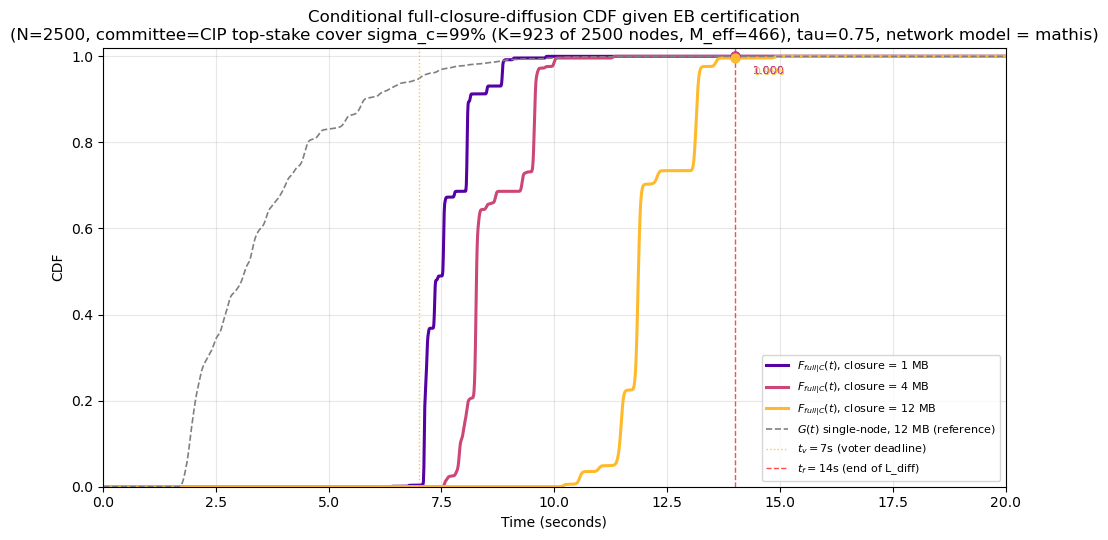

In [20]:
def plot_full_closure_diffusion_given_cert(
    sizes_kb=(1024, 4096, 12288),
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
    include_validation=True,
):
    """
    §5.6: F_{full|C}(t) under the closure model for several S_EB_tx sizes, with the
    single-node closure CDF G(t) at the largest size as a lower-bound reference.
    Annotates F_{full|C}(t_diff_end) at the L_diff deadline.
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(sizes_kb)))

    for s_kb, color in zip(sizes_kb, cmap):
        cdf_cond = cdf_full_closure_diffusion_given_cert(
            s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, stake_cover=stake_cover,
            include_validation=include_validation,
        )
        ax.plot(TIMES, cdf_cond, lw=2.2, color=color,
                label=f"$F_{{full|C}}(t)$, closure = {s_kb / 1024:.0f} MB")

        f_at_deadline = success_within(cdf_cond, t_diff_end)
        ax.scatter([t_diff_end], [f_at_deadline], color=color, zorder=5, s=40)
        ax.annotate(
            f"{f_at_deadline:.3f}",
            xy=(t_diff_end, f_at_deadline),
            xytext=(t_diff_end + 0.4, f_at_deadline - 0.04),
            fontsize=8, color=color,
        )

    # Reference: single-node closure-completion CDF at the largest size (optimistic
    # lower bound on "any single node by t").
    ax.plot(TIMES, cdf_closure_completion(max(sizes_kb), include_validation),
            ls="--", lw=1.2, color="gray",
            label=f"$G(t)$ single-node, {max(sizes_kb) / 1024:.0f} MB (reference)")

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v = {t_vote:g}$s (voter deadline)")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f = {t_diff_end:g}$s (end of L_diff)")

    ax.set_xlim(0, 20); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(
        "Conditional full-closure-diffusion CDF given EB certification\n"
        f"(N={n_nodes}, "
        f"committee={_committee_label(n_nodes, stake_cover)}, "
        f"tau={tau}, network model = {NETWORK_MODEL})"
    )
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout(); plt.show()


def print_full_closure_diffusion_summary(
    sizes_kb=(1024, 4096, 12288),
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
    include_validation=True,
):
    M, _, S_active = _committee_moments(n_nodes, stake_cover)
    print(f"  committee: {_committee_label(n_nodes, stake_cover)}")
    print(f"  quorum threshold = tau * total active stake = {tau * S_active:.0f} "
          f"(committee weight M = {M:.0f})")
    print(f"  S_EB_tx   G(t_v)  G(t_f)  P(C)     F_{{full|C}}(t_f)  G(t_f)^N")
    print("  " + "-" * 70)
    for s_kb in sizes_kb:
        G = cdf_closure_completion(s_kb, include_validation)
        g_tv = success_within(G, t_vote)
        g_tf = success_within(G, t_diff_end)
        pC = float(_quorum_given_honest_ontime(
            g_tv, n_nodes, tau, 0.0, "active", stake_cover=stake_cover))
        f_cl = success_within(
            cdf_full_closure_diffusion_given_cert(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, stake_cover=stake_cover,
                include_validation=include_validation),
            t_diff_end)
        f_uncond = g_tf ** n_nodes
        print(f"  {s_kb / 1024:>5.0f} MB  {g_tv:.4f}     {g_tf:.4f}     {pC:.4f}   "
              f"{f_cl:.4f}            {f_uncond:.3e}")


# Conservative reference network model.
set_network_model("mathis")
print_full_closure_diffusion_summary()
plot_full_closure_diffusion_given_cert()


### 5.7 Adversarial committee

§5.6 with $\beta=0$ assumed an all-honest committee.  Suppose instead a fraction
$\beta$ of the committee **stake** is Byzantine (say $\beta = 0.25$): the
adversary controls $\beta M$ of the fixed committee's weight $M$ and the honest
SPOs the remaining $(1-\beta)M$; the honest node population shrinks to
$N_h = (1-\beta)N$.  The §5.6 derivation goes through unchanged — the
committee / quorum argument never touches the per-node arrival law $G$ — except
for the composition of the stake-weighted quorum function $Q$.  In both threat
models

$$F_{\text{full}\mid C}(t)\;=\;G(t)^{N_h}\cdot
\dfrac{Q\!\bigl(\min(G(t_v)/G(t),1)\bigr)}{Q\!\bigl(G(t_v)\bigr)}\qquad,$$

with $P(C)=Q(G(t_v))$, and the two models differ **only** in how the adversary's
$\beta M$ seats enter $Q$.  $\beta=0$ recovers §5.6.  Concretely, at honest
on-time probability $p$ the honest votes contribute mean $(1-\beta)Mp$ and
variance $(1-\beta)M_2\,p(1-p)$ to the vote total $V_\text{cert}$; the quorum
is $\theta=\tau\,S_\text{active}=\tau M/\sigma_c$ throughout ($\tau$ of the total
active stake).

#### (a) Active adversaries — vote without diffusing  *(the case that matters)*

This is the threat model that actually stresses **Security Assumption 1**.  The
adversaries cast their $\beta M$ stake-weighted votes *regardless* of whether
honest diffusion reached them — they may be the EB producer, or collude to obtain
the EB out-of-band — and the protocol cannot tell their votes from honest ones.
They are always "on time" ($p=1$), adding mean $\beta M$ and **zero added
variance** (their $\beta M$ seats are deterministic) to $V_\text{cert}$.
The honest seats then only need to top the quorum up to $\theta$, i.e. an
**expected $(\tau/\sigma_c-\beta)M$** honest on-time votes instead of
$(\tau/\sigma_c)M$.  This **weakens the conditioning** — an EB can certify while
*fewer honest nodes have actually completed it* — so $F_{\text{full}\mid C}$
drops **below** the honest baseline: the certificate becomes a *weaker* witness
that closure diffusion has occurred.

As $\beta \uparrow \tau/\sigma_c$ the honest requirement
$(\tau/\sigma_c-\beta)M \to 0$: certification becomes certain ($Q\to 1$),
$F_{\text{full}\mid C}(t)\to G(t)^{N_h}$, and the certificate carries **no
information whatsoever** about honest diffusion.  The conditional guarantee
therefore degrades smoothly from the honest baseline at $\beta=0$ to the
*unconditional* honest-max curve as $\beta\uparrow\tau/\sigma_c$.

This is the practically important reading: **under an active adversary holding up
to a fraction $\tau/\sigma_c$ of the committee stake, certification provides
progressively less assurance that the EB closure has actually reached the honest
network**, and the §5.6 conditional curve is optimistic by a margin that grows
with $\beta$.

#### (b) Silent adversaries — withhold votes  *(benign reference)*

If the same $\beta$ adversaries instead simply **withhold** their votes, the
honest seats alone must meet the absolute quorum $\theta=\tau M/\sigma_c$ (the
adversary contributes nothing to $V_\text{cert}$).  Since honest stake tops out
at $(1-\beta)M$, this is feasible only if $(1-\beta)\ge\tau/\sigma_c$, i.e.
$\beta \le 1-\tau/\sigma_c \approx 0.24$ at $\tau=0.75,\ \sigma_c=0.99$ — so the
default $\beta=0.25$ sits *just past* the boundary and the silent quorum is
effectively unreachable ($P(C)\to 0$).  Withholding only makes certification
**rarer**, while each surviving certificate is *stronger* evidence, so
$F_{\text{full}\mid C}$ rises *above* the honest baseline.  Because this
direction *helps* Security Assumption 1, it is the benign case, included only as
the opposite bound.

#### Summary

| Model            | adversary seats in $V_\text{cert}$ | honest votes needed (mean) | Feasible when | Effect on $F_{\text{full}\mid C}$ |
|------------------|------------------------------------|----------------------------|---------------|-----------------------------------|
| **Active** (vote w/o diffusing) | $+\beta M$ always-on-time (zero added variance) | $(\tau/\sigma_c-\beta)M$ | $\beta < \tau/\sigma_c$ (info-free at $\beta\ge\tau/\sigma_c$) | **lower — erodes the guarantee** |
| Honest ($\beta=0$) | —                                | $(\tau/\sigma_c)M$        | always        | baseline                          |
| Silent (withhold) | —                                 | $(\tau/\sigma_c)M$ (from $\le(1-\beta)M$) | $\beta\le 1-\tau/\sigma_c$ | higher (benign)               |

The active curve is the security-relevant lower bound; the honest baseline and
the silent curve sit above it.  Because closure completion is strictly slower
than body receipt, these curves already sit lower than a body-only model would,
and the gap widens with $S_{EB\text{-}tx}$ — so the active-adversary curve at
large closure sizes is the binding case against Security Assumption 1.


  committee: CIP top-stake cover sigma_c=99% (K=923 of 2500 nodes, M_eff=466)
  M=923, tau=0.75, beta=0.25, t_f=14.0s, network=mathis
  quorum threshold = tau * total active stake = 699; active adversary adds ~beta*M = 231 votes
  S_EB_tx  model    P(C)        F_full|C(t_f)
  --------------------------------------------------
     1MB  active  1.000e+00   1.0000
     1MB  honest  1.000e+00   1.0000
     1MB  silent  5.345e-07   1.0000

     4MB  active  1.000e+00   1.0000
     4MB  honest  1.000e+00   1.0000
     4MB  silent  8.476e-06   1.0000

    12MB  active  1.000e+00   0.9970
    12MB  honest  1.000e+00   0.9960
    12MB  silent  8.994e-08   0.9973



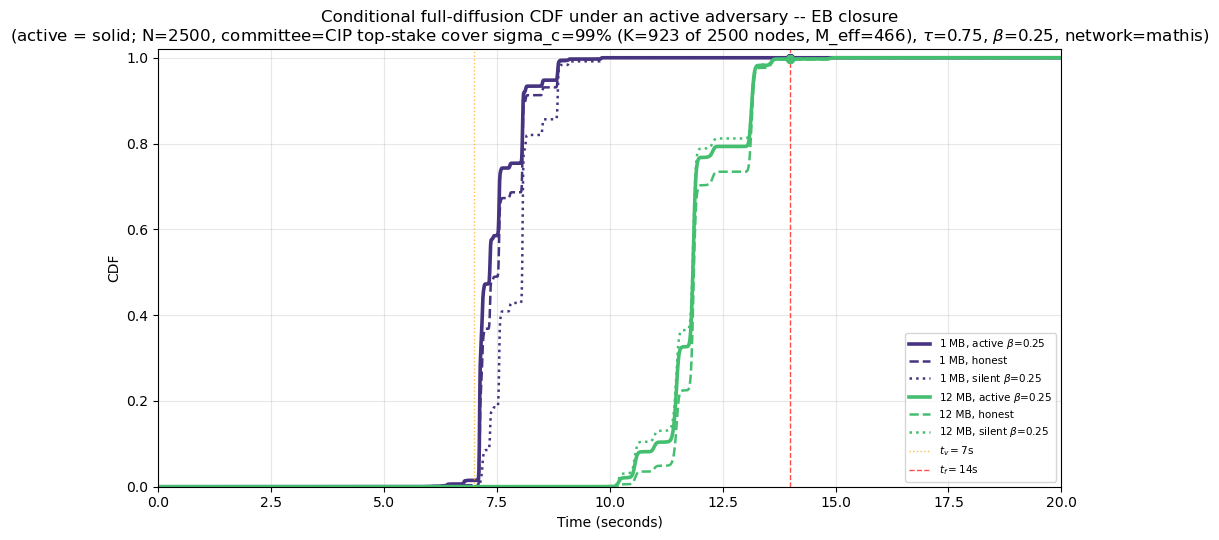

In [21]:
# §5.7: the adversarial-committee analysis reuses the §5.6 closure model -- the
# committee / quorum argument is independent of the per-node arrival law, so only
# the stake-weighted quorum (and N_h) change with beta.  The helpers are generic
# in the conditional-CDF function `cdf_fn` and default to the closure model, and
# accept the same `stake_cover` (sigma_c) parameter as §5.6.

def _adv_configs(beta):
    """(plot-label, beta, adversary, linestyle); active first to emphasise it."""
    return [
        ("active " + r"$\beta$=" + f"{beta:g}", beta, "active", "-"),
        ("honest", 0.0, "active", "--"),
        ("silent " + r"$\beta$=" + f"{beta:g}", beta, "silent", ":"),
    ]


def plot_full_diffusion_adversarial(
    cdf_fn=cdf_full_closure_diffusion_given_cert,
    sizes_kb=(1024, 12288),
    fmt_size=lambda s: f"{s / 1024:.0f} MB",
    model_label="EB closure",
    beta=0.25,
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
):
    """
    5.7: overlay F_{full|C}(t) for the security-relevant ACTIVE adversary against
    the honest baseline and the benign silent-adversary case, for several closure
    sizes.

    Active adversaries vote without diffusing (their beta*M stake-weighted seats
    lower the honest quorum requirement) -> curve sits BELOW honest: the
    certificate is a weaker witness of honest diffusion.
    Silent adversaries withhold votes (honest stake alone must reach the quorum
    tau*S_active, feasible only while (1-beta) >= tau/sigma_c) -> curve sits ABOVE
    honest (benign).
    """
    fig, ax = plt.subplots(figsize=(10, 5.5))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.7, len(sizes_kb)))

    for s_kb, color in zip(sizes_kb, cmap):
        for label, b, adv, ls in _adv_configs(beta):
            cdf_cond = cdf_fn(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=b, adversary=adv,
                stake_cover=stake_cover,
            )
            lw = 2.6 if label.startswith("active") else 1.8
            ax.plot(TIMES, cdf_cond, lw=lw, color=color, ls=ls,
                    label=f"{fmt_size(s_kb)}, {label}")
            f_at = success_within(cdf_cond, t_diff_end)
            ax.scatter([t_diff_end], [f_at], color=color, zorder=5, s=30)

    ax.axvline(t_vote, color="orange", ls=":", lw=1, alpha=0.7,
               label=f"$t_v={t_vote:g}$s")
    ax.axvline(t_diff_end, color="red", ls="--", lw=1, alpha=0.7,
               label=f"$t_f={t_diff_end:g}$s")
    ax.set_xlim(0, 20); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
    ax.set_title(
        f"Conditional full-diffusion CDF under an active adversary -- {model_label}\n"
        f"(active = solid; N={n_nodes}, "
        f"committee={_committee_label(n_nodes, stake_cover)}, "
        + r"$\tau$=" + f"{tau}, " + r"$\beta$=" + f"{beta:g}, "
        f"network={NETWORK_MODEL})"
    )
    ax.legend(loc="lower right", fontsize=7.5)
    fig.tight_layout(); plt.show()


def print_full_diffusion_adversarial_summary(
    cdf_fn=cdf_full_closure_diffusion_given_cert,
    g_fn=cdf_closure_completion,
    sizes_kb=(1024, 4096, 12288),
    fmt_size=lambda s: f"{s / 1024:>4.0f}MB",
    size_col="S_EB_tx",
    beta=0.25,
    n_nodes=2500,
    tau=0.75,
    t_vote=7.0,
    t_diff_end=14.0,
    stake_cover=0.99,
):
    # active listed first (security-relevant); honest and silent as references.
    configs = [("active", beta, "active"),
               ("honest", 0.0, "active"),
               ("silent", beta, "silent")]
    M, _, S_active = _committee_moments(n_nodes, stake_cover)
    print(f"  committee: {_committee_label(n_nodes, stake_cover)}")
    print(f"  M={M:.0f}, tau={tau}, beta={beta}, t_f={t_diff_end}s, "
          f"network={NETWORK_MODEL}")
    print(f"  quorum threshold = tau * total active stake = {tau * S_active:.0f}; "
          f"active adversary adds ~beta*M = {beta * M:.0f} votes")
    print(f"  {size_col:<6s}  model    P(C)        F_full|C(t_f)")
    print("  " + "-" * 50)
    for s_kb in sizes_kb:
        G = g_fn(s_kb)
        g_tv = success_within(G, t_vote)
        for label, b, adv in configs:
            pC = float(_quorum_given_honest_ontime(
                g_tv, n_nodes, tau, b, adv, stake_cover=stake_cover))
            cdf_cond = cdf_fn(
                s_kb, n_nodes=n_nodes, tau=tau, t_vote=t_vote, beta=b, adversary=adv,
                stake_cover=stake_cover,
            )
            f_cond = success_within(cdf_cond, t_diff_end)
            print(f"  {fmt_size(s_kb)}  {label:<6s}  "
                  f"{pC:.3e}   {f_cond:.4f}")
        print()


# Conservative reference network model, matching the §5.6 baseline plot.
set_network_model("mathis")
print_full_diffusion_adversarial_summary()
plot_full_diffusion_adversarial()


### Outcome diagram (schematic)

Visual flow of the two mutually exclusive RB validation paths after the bug
fix in §3.1.  This is the schematic referenced in §3 and §4.4.


In [22]:
def plot_outcome_diagram():
    """
    Schematic outcome diagram for the improved Linear Leios model.
    Two paths depending on whether the EB was certified.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 12)
    ax.set_ylim(-0.5, 6.5)
    ax.axis("off")
    ax.set_title(
        "Improved Linear Leios – RB Validation Outcome Diagram\n"
        "(fixing the 'cert XOR txs' RB structure)",
        fontsize=12,
        pad=10,
    )

    props_box = dict(boxstyle="round,pad=0.4", facecolor="#e8f4fd", edgecolor="#2980b9")
    props_op = dict(boxstyle="circle,pad=0.3", facecolor="#fdebd0", edgecolor="#e67e22")
    props_start = dict(
        boxstyle="round,pad=0.4", facecolor="#d5f5e3", edgecolor="#27ae60"
    )
    props_end = dict(boxstyle="round,pad=0.4", facecolor="#fdedec", edgecolor="#e74c3c")
    props_choice = dict(
        boxstyle="round,pad=0.3", facecolor="#f9ebea", edgecolor="#c0392b"
    )

    def box(ax, x, y, txt, props, fontsize=8, width=1.8, ha="center"):
        ax.text(x, y, txt, ha=ha, va="center", fontsize=fontsize, bbox=props, wrap=True)

    # Start
    box(ax, 1.0, 3.0, "RB header\nreceived", props_start, fontsize=8)
    ax.annotate(
        "",
        xy=(2.2, 3.0),
        xytext=(1.9, 3.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Choice diamond
    box(ax, 2.8, 3.0, "cert?\np_cert", props_choice, fontsize=7)

    # Upper branch: CERT path
    ax.annotate(
        "",
        xy=(4.0, 5.0),
        xytext=(2.8, 3.5),
        arrowprops=dict(arrowstyle="->", color="#27ae60"),
    )
    ax.text(3.1, 4.5, "yes", fontsize=7, color="#27ae60")

    box(ax, 5.0, 5.5, "Fetch\ncertRB body\n(~8 kB, blended)", props_box, fontsize=7)
    box(ax, 5.0, 4.5, "Fetch EB body\n(≤512kB, blended)", props_box, fontsize=7)
    box(
        ax,
        7.0,
        4.5,
        "Fetch missing\nEB-closure txs\n(π₁·S_EB-tx, 1-hop)",
        props_box,
        fontsize=7,
    )

    ax.annotate(
        "",
        xy=(6.1, 4.5),
        xytext=(5.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # last-to-finish of cert_rb and eb_closure
    box(ax, 8.3, 5.0, "last\nto\nfinish", props_op, fontsize=7)
    ax.annotate(
        "",
        xy=(8.0, 5.3),
        xytext=(6.0, 5.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(8.0, 4.8),
        xytext=(7.9, 4.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    # then reapply
    box(ax, 9.5, 5.0, "Reapply EB\ntxs (≤16k tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(9.0, 5.0),
        xytext=(8.6, 5.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Lower branch: TX path
    ax.annotate(
        "",
        xy=(4.0, 1.0),
        xytext=(2.8, 2.5),
        arrowprops=dict(arrowstyle="->", color="#c0392b"),
    )
    ax.text(3.1, 1.5, "no", fontsize=7, color="#c0392b")

    box(ax, 5.0, 1.0, "Fetch txRB body\n(≤90kB, blended)", props_box, fontsize=7)
    box(ax, 7.5, 1.0, "Apply txs\n(≤100 tx)", props_box, fontsize=7)
    ax.annotate(
        "",
        xy=(6.5, 1.0),
        xytext=(6.0, 1.0),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # End
    box(ax, 10.8, 3.0, "RB\nvalidated", props_end, fontsize=8)
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(9.5, 3.5),
        arrowprops=dict(arrowstyle="->", color="black"),
    )
    ax.annotate(
        "",
        xy=(10.3, 3.0),
        xytext=(8.5, 1.2),
        arrowprops=dict(arrowstyle="->", color="black"),
    )

    # Annotations
    ax.text(
        0.1,
        6.2,
        "Key: cert path = RB holds EB certificate.  "
        "tx path = RB holds transactions.",
        fontsize=7,
        style="italic",
    )
    ax.text(
        0.1,
        5.9,
        "In the existing model these paths were incorrectly forced in parallel.",
        fontsize=7,
        color="red",
    )

    fig.tight_layout(); plt.show()


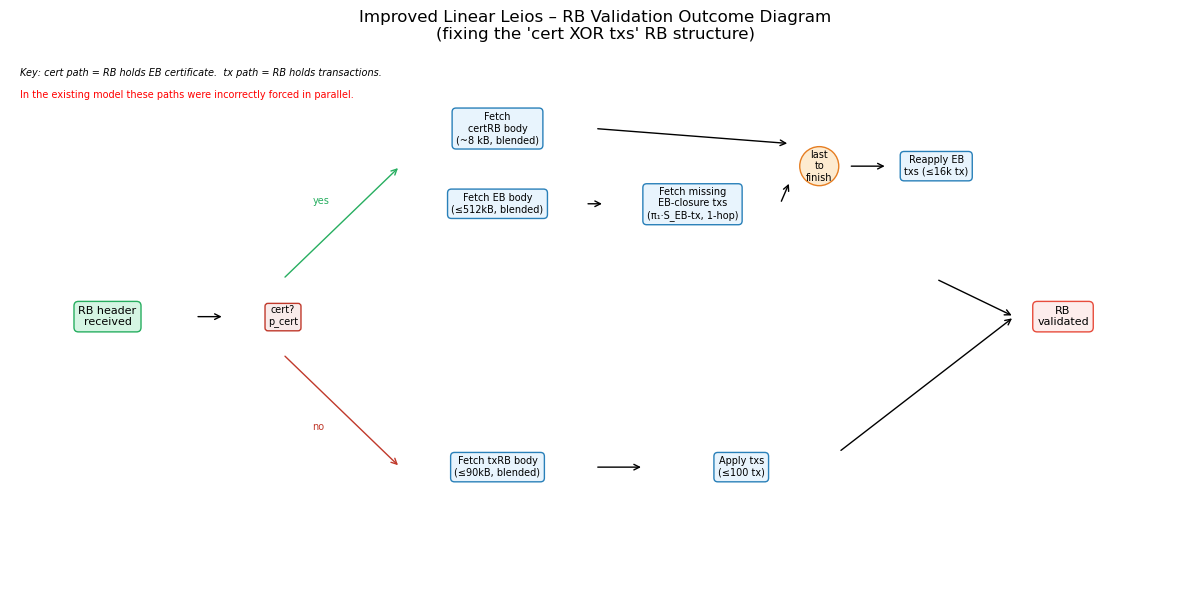

In [23]:
plot_outcome_diagram()


**`outcome_diagram`**

**What it shows.** A schematic (non-data) flow diagram of the two mutually
exclusive RB validation paths.  With probability $p_\text{cert}$ the RB is a
*certRB*: the node downloads the small RB header, fetches the EB body, applies
(or reapplies) the EB closure transactions, and verifies the certificate.  With
probability $1 - p_\text{cert}$ the RB is a *txRB*: the node downloads the
header and a ≤ 90 kB transaction payload and applies those transactions
directly.

**Why it matters.** This diagram is the visual summary of Bug Fix 1 (Section 3).
The prior model forced *both* paths to run in parallel on every RB; this
diagram illustrates why that was wrong and what the correct probabilistic
choice model looks like.

## 6. Comparison with Prior Analysis

| Aspect                      | Prior model                         | Improved model              |
|-----------------------------|-------------------------------------|-----------------------------|
| RB structure                | Both tx + cert paths forced always  | Probabilistic choice p_cert |
| EB closure size (model)     | Implicit; N=2500 hardcoded          | Explicit sweep 0–12 MB      |
| Reapply distribution        | Scale mixture U(1,N): mean N/2 txs  | Fixed-N CLT: exactly N txs  |
| EB closure fetch            | Not modelled (TxCache only)         | 1-hop bulk transfer         |
| Certification probability   | Not computed; assumed fixed         | Computed from quorum model  |
| Per-tx apply time           | 10.60 ms (per-block mean)           | 0.507 ms/tx (tx-weighted)   |
| Per-tx reapply time         | 2.71 ms (per-block mean)            | 0.070 ms/tx (tx-weighted)   |
| Network transfer model      | Empirical Praos table (≤2 MB data)  | TCP slow-start + selectable steady-state (Mathis / CUBIC) |
| P(≤14s) in prior model      | 0.9740 (single point)               | Not directly comparable (different RB structure) |
| P_cert at 12 MB (Mathis)    | Not computed                        | 0.497 (at Praos cap)        |
| P_cert at 12 MB (CUBIC)     | Not computed                        | 0.497 (at Praos cap)        |

The prior analysis reported P(≤14s) = 0.974 for its (incorrect)
single-scenario model, which was cited as validation of the CIP parameters.
That figure was inflated by three independent errors: (a) the scale mixture
underestimating reapply time by 2×; (b) the RB structure bug mixing
mutually exclusive paths; and (c) the per-tx timing constants being
per-block means rather than per-tx costs (≈ 20–40× overstatement).

Under fully corrected assumptions, the CIP target of 12 MB is **robustly
feasible under both Mathis and CUBIC** at $\pi_1 = 1/6$ and below: CPU is
non-binding (single-core ceiling ≈ 38 MB); the 2 MB missing-closure fetch
over 268 ms RTT (long-haul) takes ≈ 4.4 s under Mathis and ≈ 2.0 s under
CUBIC — both within the 7 s voter deadline.  $P_\text{validating} \geq 0.95$
under either model, $P_\text{quorum} \approx 1.0$, and $P_\text{cert}$
stays at the Praos cap of $\approx 0.497$.

## 7. Limitations and Assumptions

1. **1-hop approximation for EB closure fetch.** The model assumes each node
   can obtain missing transactions from its upstream peer in a single hop.
   If the raw transactions making up the closure have *not* pre-diffused via
   tx-submission (e.g., under adversarial withholding or heavy load), the full
   closure must traverse the blended multi-hop network.  At 12 MB this
   full-blended diffusion succeeds within 14 s only **14%** of the time under
   Mathis and **99%** under CUBIC (§5.2).  The corresponding voter pipeline
   still yields $P_\text{cert} \approx 0$ under either model — the 7 s voter
   deadline and 75% quorum threshold are both tighter than the 14 s network
   delivery alone, so even CUBIC's near-100% network-delivery rate doesn't
   prevent the quorum failure.  See **§5.3 "Full-blended worst case"** for
   the full derivation and the $\alpha$-mixture formulation.  The 1-hop
   model is only valid when pre-diffusion via tx-submission is effective.

2. **Average transaction size = 1 kB.** The CIP uses 2 kB in some places. At
   2 kB/tx, a 12 MB closure has half as many tx hashes (so a smaller EB
   body) and half the missing-closure-fetch size for cache misses.  Since
   12 MB is already feasible at 1 kB/tx, the 2 kB/tx case
   would only widen the feasibility margin.

3. **Single scalar $\pi_1$ rather than a Markov chain fit.**  §5.5 and
   `pi1_derivation.ipynb` now provide an empirically-derived steady-state
   value ($\pi_1 \approx 0.06$ cross-region BAU mean, 0.085 worst-pair),
   replacing the prior model's hand-chosen $p = 0.5,\, q = 0.9$ Markov
   parameters (which yielded $\pi_1 = 1/6$).  What remains a limitation is
   that we use the steady-state mean only, without re-fitting the
   underlying $(p, q)$ to the tx-arrival time series — temporal
   stickiness in mempool divergence is therefore not captured.  §5.5
   sweeps $\pi_1$ to bound the residual uncertainty.

4. **Fixed binary miss fraction — no heterogeneity across nodes.**
   The TxCache model collapses to a single constant: each node is either a
   *cache hit* (probability $\pi_2 = 5/6$, holds the full closure, 1 ms lookup)
   or a *cache miss* (probability $\pi_1 = 1/6$, must fetch exactly
   $\pi_1 \cdot S_{EB-tx}$ from one hop).  There is no state in between.
   In reality, nodes have a continuous distribution of miss fractions depending
   on network position, uptime, and mempool composition; in particular, a node
   with a cold or empty mempool could be missing the **entire** closure.

   For the CIP-0164 target $S_{EB-tx} = 12$ MB, the assumed cache-miss
   fetch is $\pi_1 \times 12\,\text{MB} \approx 2\,\text{MB}$.  A node
   missing 100% of the closure would instead need to fetch the full
   12 MB — approximately 6× more data.  Over a long-haul link this 1-hop
   transfer takes ≈ 3.6 s under CUBIC and ≈ 23.7 s under Mathis;
   combined with the EB body fetch (~1 s blended) and CPU reapply
   (~1.8 s), a cold-mempool node sits at ~6.5 s total under CUBIC
   (tight but inside the 7 s deadline) and well over the deadline under
   Mathis.  The fixed-fraction assumption therefore overstates
   feasibility for cold-mempool nodes under Mathis; under CUBIC the
   margin is narrower but the cold-node case is still mostly
   recoverable.

5. **No adversarial behaviour.** The model assumes honest nodes that always
   diffuse transactions promptly via tx-submission before the EB is produced.
   An adversary that deliberately withholds transactions from tx-submission
   invalidates the 1-hop approximation and could force the full multi-hop
   diffusion scenario, reducing the feasible range significantly.

6. **TCP throughput model assumptions.**
   The transfer-time model uses TCP slow start from $\text{cwnd}_0 = 10$ MSS
   (14 600 B), capped at a model-specific steady-state window $W_\text{ss}$
   (Mathis: 146 000 B; CUBIC: 1 538 590 B at $p = 10^{-4}$).  Common
   assumptions:

   - *MSS = 1460 B, cwnd₀ = 10 MSS.*  Modern Linux kernels use IW10 (RFC 6928);
     TLS adds a 5-byte record header reducing effective MSS slightly.  Idle-
     restart and connection reuse can lower the effective cwnd₀.
   - *One-way delays.*  Short (6 ms), medium (34.5 ms), and long (134 ms),
     derived from Table 1 of the Praos paper (`PraosModel.pdf`) which gives
     RTTs of 12 / 69 / 268 ms for these distance categories (we halve to
     get OWDs).  The long RTT (268 ms) reflects typical intercontinental
     paths; true 95th-percentile South America–Asia-Pacific paths (which
     have no direct undersea cable) may reach 300–400 ms RTT, so the long
     category is mildly optimistic for that specific worst case.  A higher
     OWD increases the number of slow-start RTTs before reaching
     $W_\text{ss}$ and dominates transfer time for large sizes.
   - *1 Gbit/s interface cap.*  Applies only if the interface is the
     bottleneck; SPO nodes with lower-bandwidth connections would see worse
     numbers.  The bandwidth-delay product $\text{BDP} = 125\,\text{MB/s}
     \times \text{RTT}$ is well above either model's $W_\text{ss}$ at
     $p = 10^{-4}$ on every distance category, so the BDP cap is inactive.
   - *Persistent TCP, no handshake.*  Each fetch is assumed to use an existing
     long-lived TLS connection; cold-start RTTs (TCP 3-way + TLS handshake)
     are not included.

   Both throughput models share these assumptions; they differ only in the
   functional form of $W_\text{ss}$ (Mathis: $\propto p^{-1/2}$; CUBIC:
   $\propto p^{-3/4}$).  See §5.4 for the loss-rate sensitivity and the
   five real-world caveats (rwnd lag, short-flow slow-start dominance,
   bufferbloat, $p$ at high-traffic SPO paths, CUBIC's Reno-friendly fallback)
   that further blur the boundary between the two models.

   The full-blended diffusion results at $S_{EB-tx} > 4$ MB are the most
   model-sensitive: at 12 MB, $P(\leq 14\,\text{s})$ is 14% under Mathis
   and 99% under CUBIC.

7. **No FFD (Freshest First Delivery).** Following the prior report, FFD is
   not modelled; in practice it can delay older EBs in favour of newer ones.

8. **The voting deadline computation uses `3·L_hdr + L_vote = 7s`.** This
   implies three pipeline stages each requiring L_hdr = 1 slot before the voter
   can start. If the actual voter deadline is shorter (e.g., `L_hdr + L_vote =
   5s`), the feasible S_EB_tx is correspondingly smaller.

## 8. Recommendations

1. **The CIP-0164 target of 12 MB is robustly feasible under realistic
   mainnet conditions.**  At the empirical $\pi_1 \approx 0.06$ (§5.5,
   `pi1_derivation.ipynb`) and the Praos paper's RTT values, $P_\text{cert}
   \approx 0.497$ at 12 MB under *both* Mathis and CUBIC.  The 2 MB
   missing-closure fetch over long-haul (268 ms RTT) takes ≈ 4.4 s under
   Mathis and ≈ 2.0 s under CUBIC — both well within the 7 s voter deadline.
   The throughput-model uncertainty is immaterial in this regime; both
   models reach the Praos cap at every CIP-target size, and even at
   $\pi_1 = 1/6$ (the prior Haskell model's default), 12 MB remains
   feasible.

2. **CPU is not the binding constraint at any closure size ≤ 12 MB.**  With
   corrected per-tx costs ($\mu_\text{eff} = 0.143$ ms/tx), the single-core
   CPU ceiling is ≈ 38 MB on commodity hardware.  No special CPU provisioning
   is required for EB closure validation in this model (multi-core
   parallelism is out of scope).

3. **Ensure effective tx-submission pre-diffusion.**  The model's main
   remaining load-bearing assumption is the 1-hop approximation: transactions
   have already diffused via tx-submission before the EB is produced.  Under
   total pre-diffusion failure the effective $P_\text{cert}$ collapses to
   ≈ 0 under either throughput model at 12 MB (the 7 s voter deadline and
   75% quorum threshold both fail, regardless of whether the network
   delivers within 14 s; see §5.3 "Full-blended worst case" and the
   $\alpha$-mixture formula $P_\text{cert,effective} \approx \alpha \cdot
   P_\text{cert,1-hop}$).  Protocol parameters and node implementation
   must ensure pre-diffusion holds under normal operation.

4. **The Praos interruption probability (≈ 50%) is a hard ceiling.**
   No tuning of $S_{EB-tx}$, throughput model, or network topology
   can push $P_\text{cert}$ above ≈ 0.497 whenever quorum is met.  If higher
   certification rates are desired, the relationship between the Leios round
   length and the Praos slot rate needs revisiting.

5. **Measure the actual network conditions on the SPO mesh.**  The Mathis-vs-
   CUBIC gap is a useful proxy for our uncertainty about real-world TCP
   throughput.  Three measurements would narrow the band:
   - 95th-percentile SPO-to-SPO one-way delays (currently assumed 268 ms long-haul).
   - End-to-end packet loss on intercontinental SPO paths (currently $p = 10^{-4}$).
   - Effective receive-window autotuning state for typical SPO connections.
   See §5.4 for the corresponding loss-rate sensitivity.

6. **Adopt the empirical $\pi_1$ estimate.**  An empirical extraction from
   `post-cip/mempool-measurements/` (see `pi1_derivation.ipynb`) gives
   $\pi_1 \approx 0.06$ (cross-region mean, BAU window) with a worst-pair
   value of 0.085.  The prior model's $\pi_1 = 1/6$ is **~3× too high**.
   At the empirical value, §5.5 shows 12 MB is feasible under either
   throughput model.  Two outstanding tasks:
   - Confirm whether the unexplained high-utilization outlier from the
     us-east-2 monitoring node ($\pi_1 \approx 0.44$ on blocks at > 85%
     utilization) reflects a real incident or a measurement artifact.
   - Broaden the measurement beyond three AWS regions; SPOs on
     consumer-grade uplinks or at mesh-edge positions may have higher
     miss rates than the well-connected datacentre instrumentation.

7. **Verify the average transaction size assumption.**  At 2 kB/tx rather
   than 1 kB/tx, the missing-closure fetch at 12 MB halves to 1 MB.  Since
   12 MB is already feasible at 1 kB/tx, the 2 kB/tx case
   only widens the margin.

8. **Re-examine the per-tx timing constants with a richer dataset.**  The
   corrected values are transaction-weighted means from mainnet blocks with at
   most 385 transactions.  Extrapolating to EB closures of thousands of
   transactions assumes the same per-tx cost distribution, which may not hold
   if closure composition differs from mainnet blocks.

## 9. Artifact Index

| File                      | Description                                                             |
|---------------------------|-------------------------------------------------------------------------|
| `analysis.ipynb`          | This notebook — the full ΔQ analysis (code + prose, dual network model) |
| `timing_derivation.ipynb` | Derivation of the per-tx apply/reapply timing constants (with reproducing code) |
| `pi1_derivation.ipynb`    | Empirical derivation of the TxCache miss rate π₁ (with reproducing code) |

All three are standalone, self-contained notebooks; figures and numbers are produced inline when run (no SVG or JSON files are written).

**References for the throughput models:**
- Mathis et al. (1997), "The macroscopic behavior of the TCP congestion
  avoidance algorithm", ACM SIGCOMM CCR.
- Ha, Rhee, Xu (2008), "CUBIC: A new TCP-friendly high-speed TCP variant",
  ACM SIGOPS Operating Systems Review.  RFC 8312 standardises the
  Linux-kernel default.

## Interactive exploration

Edit the parameters in the cells below and re-run to explore the numbers.
The full sweep (`run_sweep`) re-evaluates the model at the parameters set by
`set_network_model(...)` and `set_cache_miss_rate(...)`.


At model=cubic, π₁=0.06, S_EB_tx=12.00 MB:
  P_validating  = 0.9974
  P_quorum      = 1.0000
  P_interrupted = 0.5034
  P_cert        = 0.4966
  P(≤7s)        = 0.9987
  P(≤14s)       = 1.0000
  Q50           = 1.45 s
  Q95           = 4.27 s
  Q99           = 5.65 s


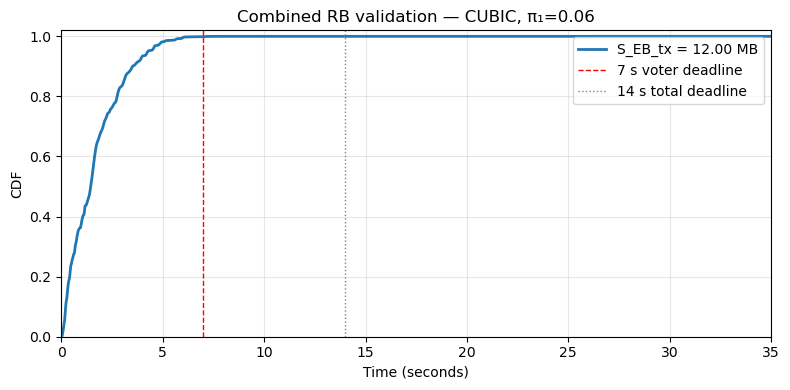

In [24]:
# === edit these and re-run the cell ============================
model = "cubic"   # 'mathis' or 'cubic'
pi1   = 0.06      # TxCache miss rate
s_kb  = 12288     # closure size in kB (use 1024 for 1 MB, 12288 for 12 MB)
# ================================================================

set_network_model(model)
set_cache_miss_rate(pi1)

info = compute_p_certified(s_kb)
cdf  = cdf_validate_rb(info["p_cert"], s_kb)
print(f"At model={model}, π₁={pi1}, S_EB_tx={s_kb/1024:.2f} MB:")
print(f"  P_validating  = {info['p_validating']:.4f}")
print(f"  P_quorum      = {info['p_quorum']:.4f}")
print(f"  P_interrupted = {info['p_interrupted']:.4f}")
print(f"  P_cert        = {info['p_cert']:.4f}")
print(f"  P(≤7s)        = {success_within(cdf, 7.0):.4f}")
print(f"  P(≤14s)       = {success_within(cdf, 14.0):.4f}")
print(f"  Q50           = {quantile_of(cdf, 0.50):.2f} s")
print(f"  Q95           = {quantile_of(cdf, 0.95):.2f} s")
print(f"  Q99           = {quantile_of(cdf, 0.99):.2f} s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(TIMES, cdf, lw=2, label=f"S_EB_tx = {s_kb/1024:.2f} MB")
ax.axvline(7.0,  color="red",  ls="--", lw=1, label="7 s voter deadline")
ax.axvline(14.0, color="gray", ls=":",  lw=1, label="14 s total deadline")
ax.set_xlabel("Time (seconds)"); ax.set_ylabel("CDF")
ax.set_xlim(0, 35); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
ax.set_title(f"Combined RB validation — {model.upper()}, π₁={pi1}")
ax.legend(); fig.tight_layout(); plt.show()

# Reset to defaults for any downstream cells.
set_network_model("mathis"); set_cache_miss_rate(1/6)


## References

- CIP-0164 – Ouroboros Leios
- `analysis/deltaq/linear-leios/docs/report.md` – Prior ΔQ analysis
- `post-cip/apply-reapply/ReadMe.md` – Ledger apply/reapply timing measurements
- `docs/deltaq_PraosModel.pdf` – Praos ΔQ analysis
- Mathis et al. (1997), *The macroscopic behavior of the TCP congestion
  avoidance algorithm*, ACM SIGCOMM CCR.
- Ha, Rhee, Xu (2008), *CUBIC: A new TCP-friendly high-speed TCP variant*,
  ACM SIGOPS Operating Systems Review.  Standardised by RFC 8312.
- `docs/deltaq_complexity_management_strategy.pdf` – Backend complexity discussion
- `docs/Praos Performance Model.pdf` – Praos performance model (p_interrupted derivation)
